# Comparing capabilties of ABMs with LSTM models to validate predictive accuracy in COVID-19 forecasting

###Import the drive to store data and Importing all the appropriate librabries required.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install the required libraries
!pip install pandas matplotlib statsmodels

import pandas as pd # Library used for data manipulation and analysis
import numpy as np # Provides support for multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays efficiently
import matplotlib.pyplot as plt # Core plotting library for creating static, animated, and interactive visualizations in Python
import seaborn as sns # Statistical data visualization library built on top of matplotlib for creating more advanced plots
from sklearn.preprocessing import StandardScaler # Standardizes features by removing the mean and scaling to unit variance
from sklearn.metrics import mean_absolute_error, mean_squared_error # Metrics for evaluating the performance of regression models, including forecasting models
from statsmodels.tsa.arima.model import ARIMA # Model for time series forecasting using ARIMA (AutoRegressive Integrated Moving Average)
from statsmodels.tsa.statespace.sarimax import SARIMAX # Model for time series forecasting using SARIMA (Seasonal ARIMA with exogenous factors)
from sklearn.model_selection import train_test_split # Utility for splitting a dataset into training and testing sets
import tensorflow as tf # Deep learning library that can be used to implement advanced neural networks like LSTM
from tensorflow.keras.models import Sequential # High-level neural networks API, capable of building models layer by layer
from tensorflow.keras.layers import Dense, LSTM # Layers for building fully connected networks and Long Short-Term Memory networks in TensorFlow
from prophet import Prophet # Time series forecasting library designed to handle seasonality, holidays, and trends automatically
import os # Library for interacting with the operating system, useful for file handling and directory navigation
import zipfile
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense


**Metadata for the Dataset Variables**

date: Time series data

susceptible: Number of individuals susceptible to infection on a given day.

exposed: Number of individuals exposed to the virus but not yet infectious.

infectious: Number of individuals currently infectious and capable of spreading the disease.

recovered: Number of individuals who have recovered from the infection.

dead: Cumulative number of deaths due to the infection.

immune: Number of individuals who are immune.

num infections today: Number of new infections reported on a given day.

num hospitalisations today: Number of new hospitalizations reported on a given day.

hospital bed occupancy: Total number of hospital beds occupied on a given day.

num hospitalisations today (data): Additional hospitalization data.

cum num hospitalisations today: Cumulative number of hospitalizations up to the given date.

cum num infections today: Cumulative number of infections up to the given date.

###1: Data Loading and Transformation.

In [ ]:
import zipfile
import pandas as pd

# Define a reusable function to handle data extraction and date conversion
def load_and_prepare_data(zip_path, csv_filename):
    """
    Function to extract data from a zip file, load the CSV, and convert 'date' column.

    Parameters:
        zip_path (str): Path to the zip file.
        csv_filename (str): Path to the CSV file inside the extracted zip.

    Returns:
        df (DataFrame): Cleaned DataFrame with 'date' column converted to datetime.
    """
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/extracted_data')  # Extract the data into a directory
        csv_file_path = f'/content/extracted_data/{csv_filename}'
        df = pd.read_csv(csv_file_path)

    # Convert 'date' column to datetime format
    df['date'] = pd.to_datetime(df['date'], dayfirst=True)

    return df

# Use the function to load both datasets
run1_df = load_and_prepare_data('/run1.zip', 'run1/klaipeda-measures_lt.csv')
run2_df = load_and_prepare_data('/run2.zip', 'run2/klaipeda-measures_lt.csv')

# Display the column names and first few rows
print(run1_df.columns)
print(run1_df.head())

# Confirm the conversion
print("\nData types after 'date' conversion")
print(run1_df.dtypes)


Index(['#time', 'date', 'susceptible', 'exposed', 'infectious', 'recovered',
       'dead', 'immune', 'num infections today', 'num hospitalisations today',
       'hospital bed occupancy', 'num hospitalisations today (data)',
       'cum num hospitalisations today', 'cum num infections today'],
      dtype='object')
   #time       date  susceptible  exposed  infectious  recovered  dead  \
0      1 2023-01-02       181647       71          47          6     9   
1      2 2023-01-03       181643       74          43          8    14   
2      3 2023-01-04       181636       77          47          8    15   
3      4 2023-01-05       181631       81          40         11    23   
4      5 2023-01-06       181630       72          52         11    23   

   immune  num infections today  num hospitalisations today  \
0  181673                    11                           7   
1  181671                     6                           5   
2  181670                     8                 

In [ ]:
# Find rows where 'date' is NaN
nan_dates = run1_df[run1_df['date'].isna()]
# Display rows with NaN in 'date'
print(nan_dates)

# remove the unnessasary entry columns
if 'num hospitalisations today (data)' in run1_df.columns:
    run1_df = run1_df.drop(columns=['num hospitalisations today (data)'])

if 'num hospitalisations today (data)' in run2_df.columns:
    run2_df = run2_df.drop(columns=['num hospitalisations today (data)'])

#7 Check for missing values in both datasets
print("\nMissing values- run1:")
print(run1_df.isnull().sum())

print("\nMissing values- run2:")
print(run2_df.isnull().sum())

# View the first few rows of the dataset to confirm cleaning
print("First 5 rows:")
print(run1_df.head())

# statistical summary
print("Statistical summary :")
print(run1_df.describe())

Empty DataFrame
Columns: [#time, date, susceptible, exposed, infectious, recovered, dead, immune, num infections today, num hospitalisations today, hospital bed occupancy, num hospitalisations today (data), cum num hospitalisations today, cum num infections today]
Index: []

Missing values- run1:
#time                             0
date                              0
susceptible                       0
exposed                           0
infectious                        0
recovered                         0
dead                              0
immune                            0
num infections today              0
num hospitalisations today        0
hospital bed occupancy            0
cum num hospitalisations today    0
cum num infections today          0
dtype: int64

Missing values- run2:
#time                             0
date                              0
susceptible                       0
exposed                           0
infectious                        0
recovered         

###2: Exploratory Data Analysis (EDA)


Total number of people infected: 18749
Percentage of intitially infected population out of the total population: 10.32%


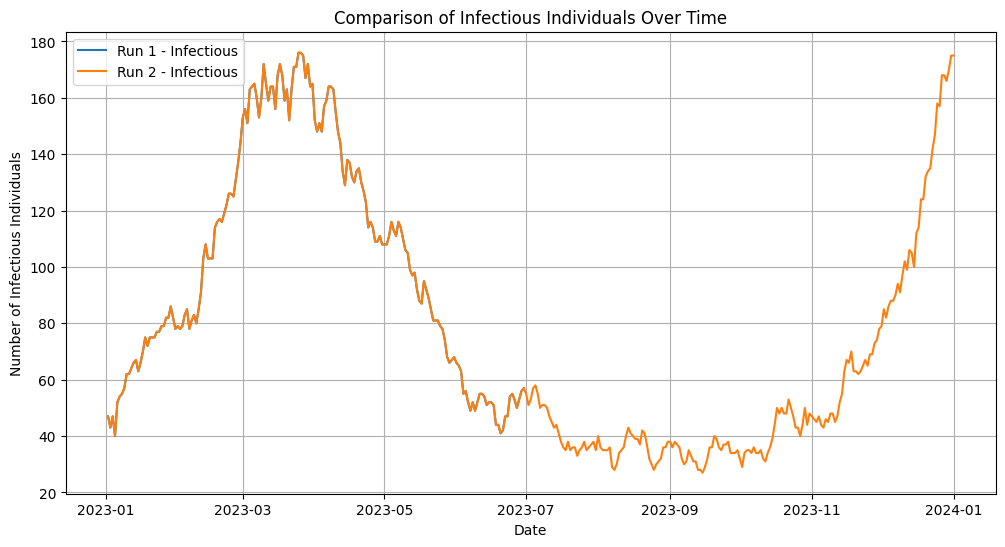

In [ ]:
# Initial number of infectious people at the start of the simulation
initial_infectious = 200

# Total number of new infections during the simulation
total_new_infections = run1_df['infectious'].sum()

# Total number of people infected (initial + new infections)
total_infected = initial_infectious + total_new_infections

# Initial total population
initial_population = run1_df[['susceptible', 'infectious', 'recovered', 'dead']].iloc[0].sum()

# Percentage of the population that was infected
percentage_infected = (total_infected / initial_population) * 100

print(f"Total number of people infected: {total_infected}")
print(f"Percentage of intitially infected population out of the total population: {percentage_infected:.2f}%")

# Plot trends over time
plt.figure(figsize=(12, 6))
plt.plot(run1_df['date'], run1_df['infectious'], label='Run 1 - Infectious')
plt.plot(run2_df['date'], run2_df['infectious'], label='Run 2 - Infectious')
plt.xlabel('Date')
plt.ylabel('Number of Infectious Individuals')
plt.title('Comparison of Infectious Individuals Over Time')

# Check for the 180 rows and add lines for better contrast
if len(run1_df) > 180:
    plt.axvline(x=run1_df['date'].iloc[180], color='r', linestyle='--', label='Forecast Start') # This line will only be executed if run1_df has more than 180 rows
plt.legend()
plt.grid(True)
plt.show()

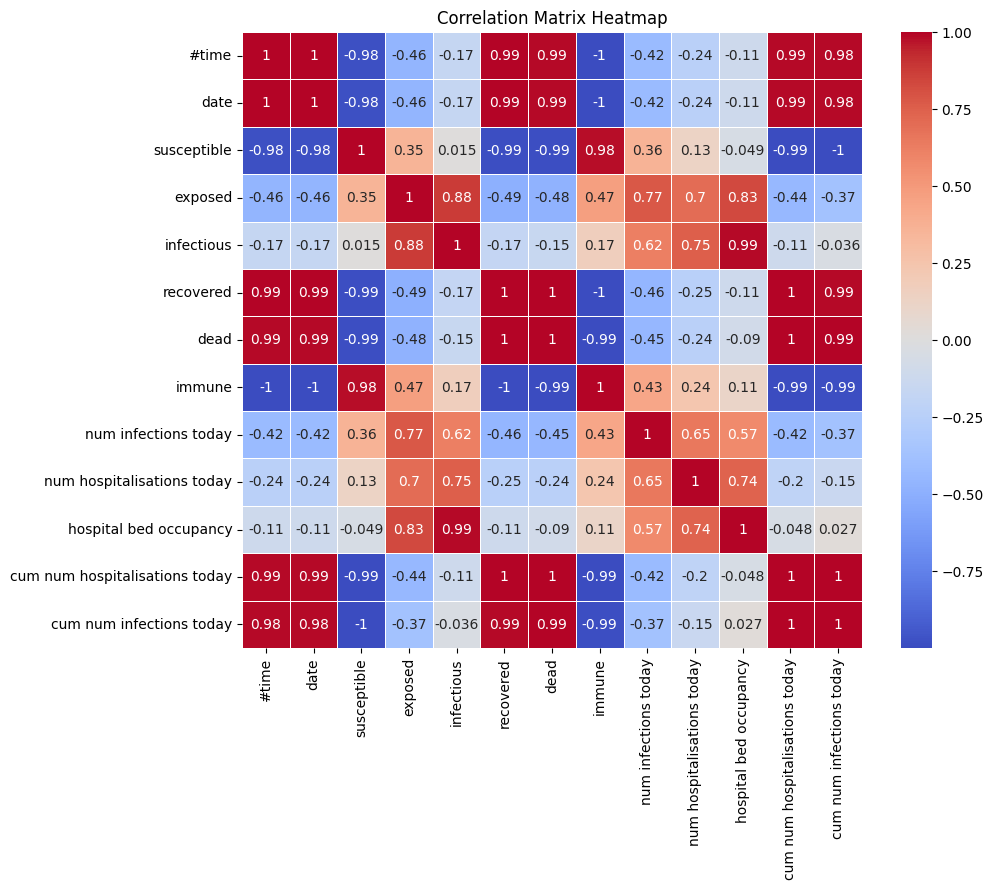

In [ ]:
# Calculate the correlation matrix to compare all the variables
corr_matrix = run1_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

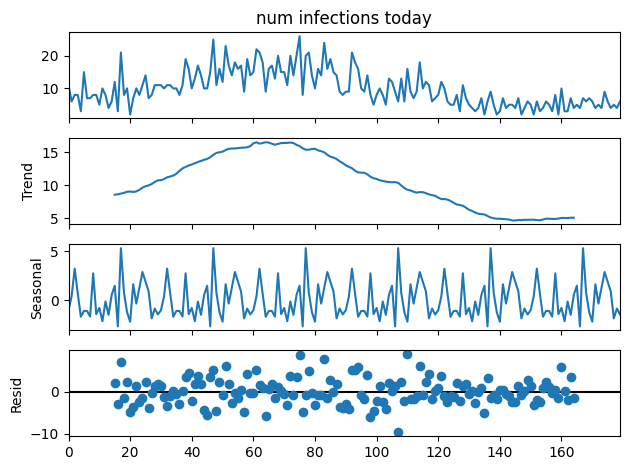

ADF Statistic: -0.6946045968972604
p-value: 0.8481421233855067


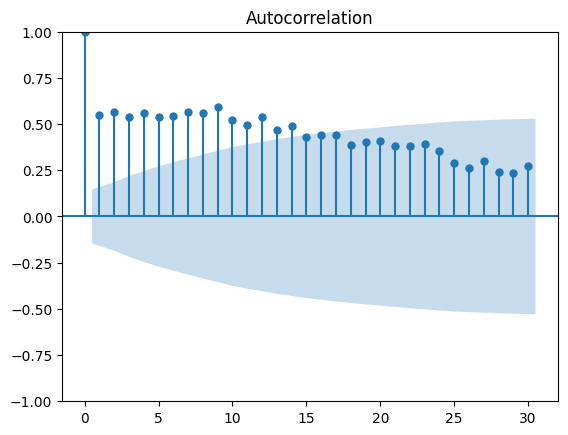

In [ ]:
# Time Series Decomposition shows the trend in the data and seasonality
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(run1_df['num infections today'], model='additive', period=30)
decomposition.plot()
plt.show()
# since its a timeseries we measure against time and look for stationarity
result = adfuller(run1_df['num infections today'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(run1_df['num infections today'], lags=30)
plt.show()


EDA Visualization (Univariate)

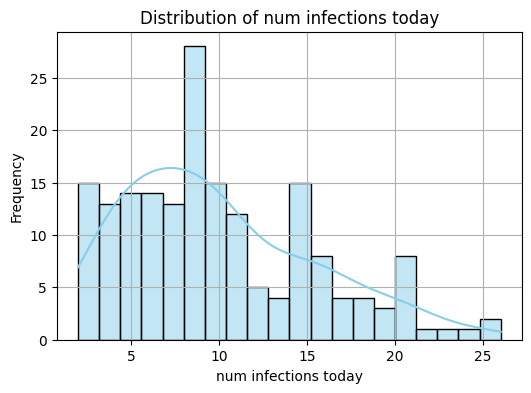

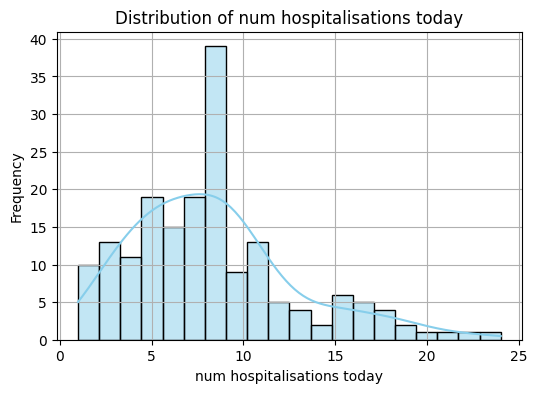

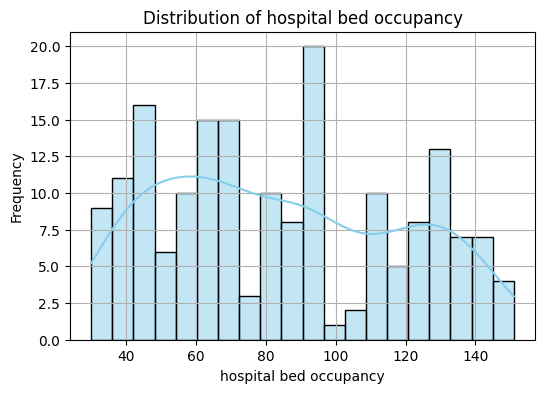

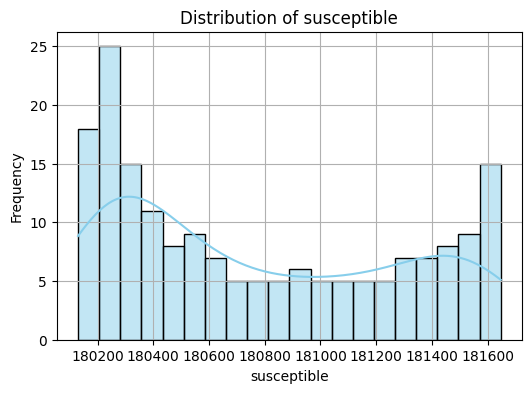

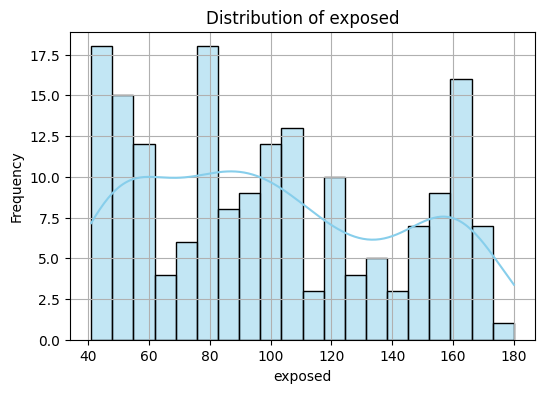

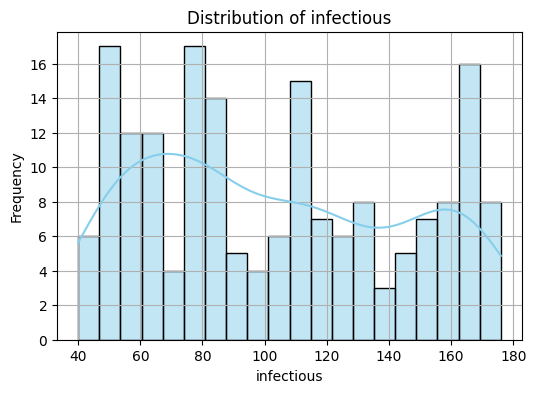

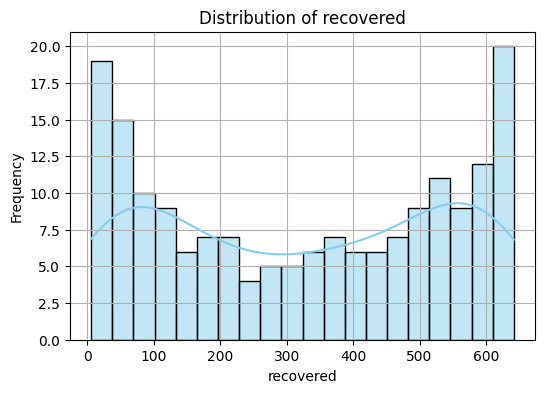

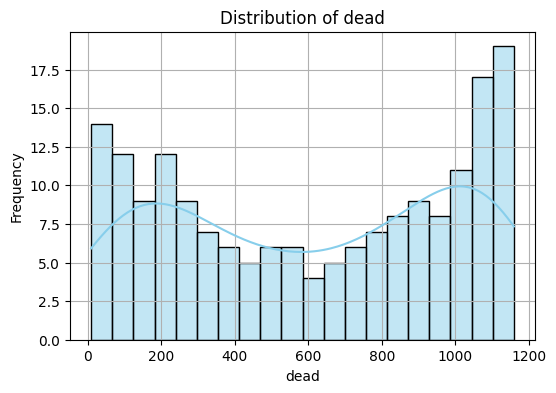

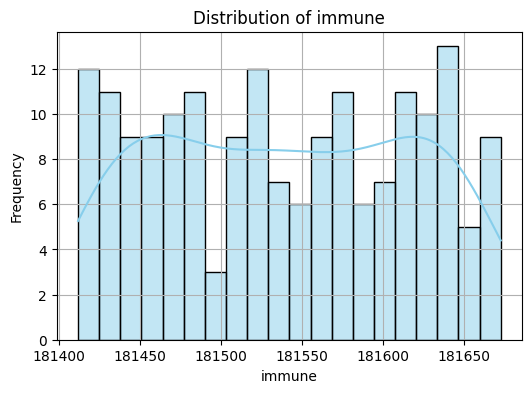

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns to analyze
numerical_columns = ['num infections today', 'num hospitalisations today', 'hospital bed occupancy', 'susceptible', 'exposed', 'infectious', 'recovered', 'dead', 'immune']

# Plotting histograms with KDE for each numerical column
for column in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(run1_df[column], bins=20, color='skyblue', edgecolor='black', kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)  # Add grid for better readability
    plt.show()


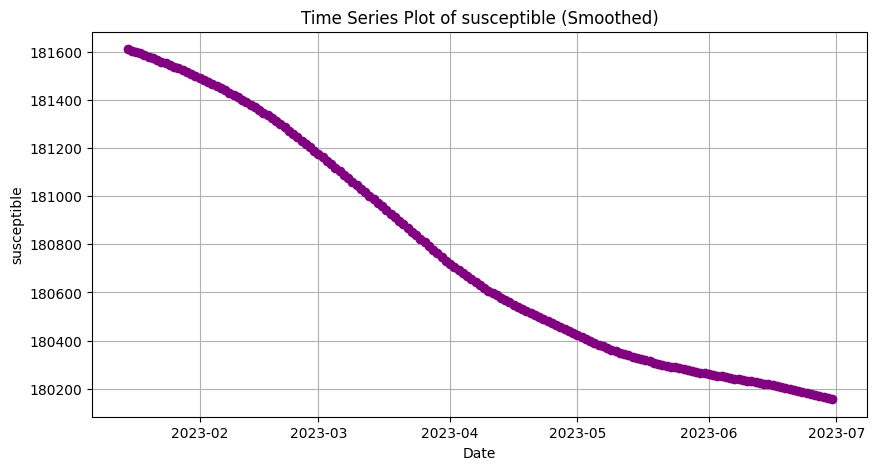

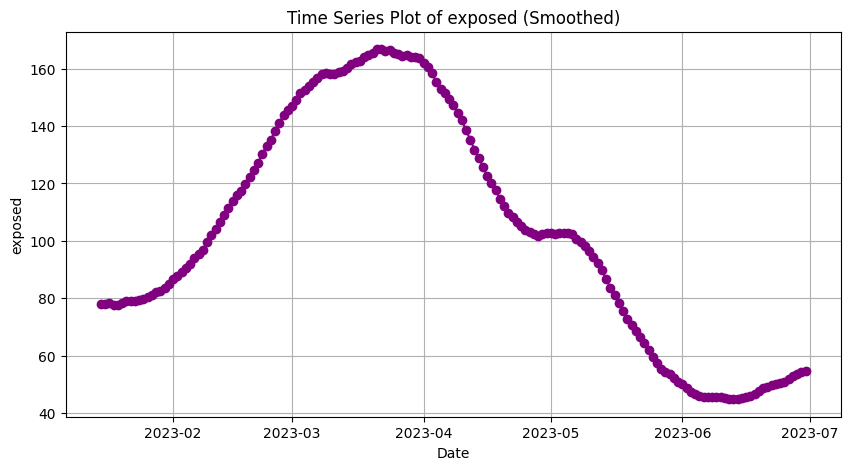

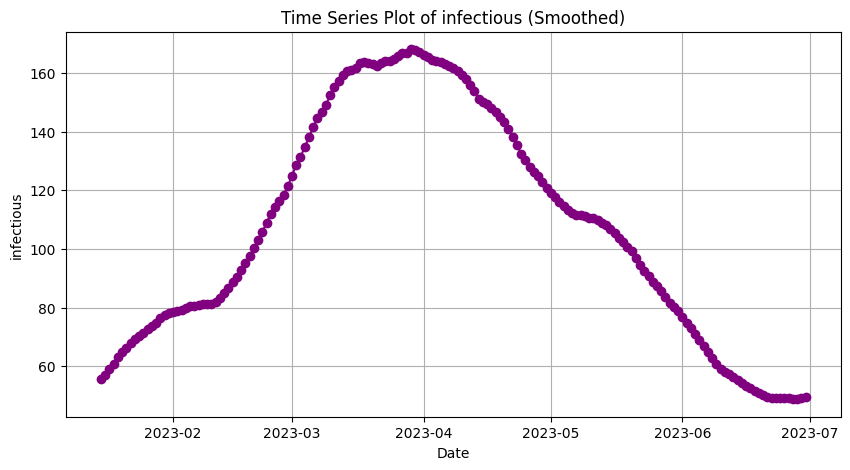

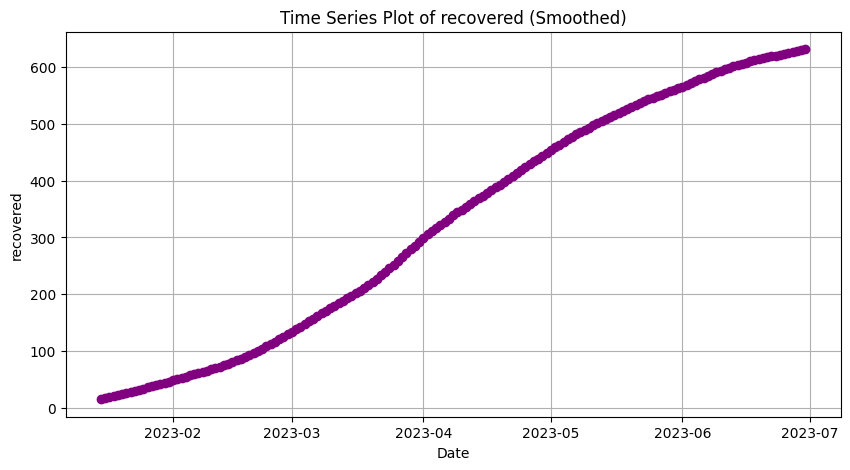

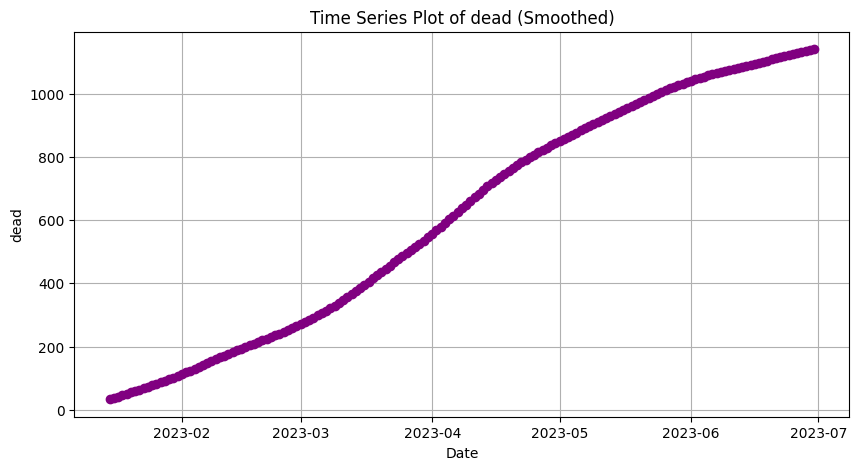

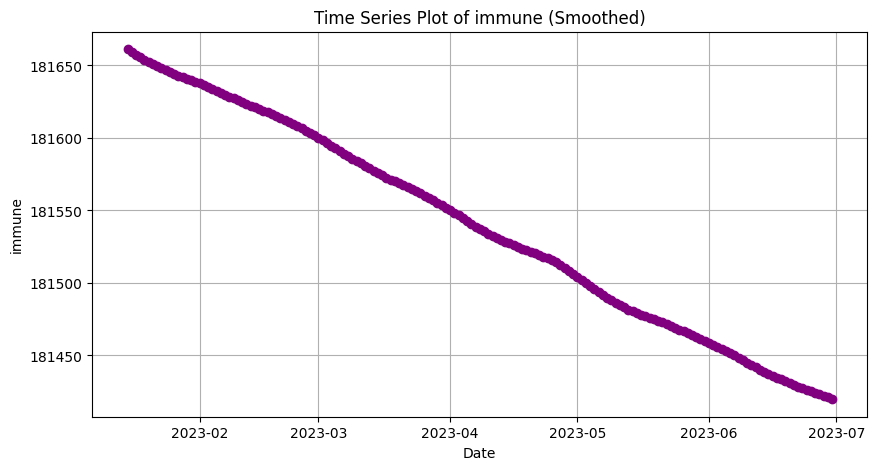

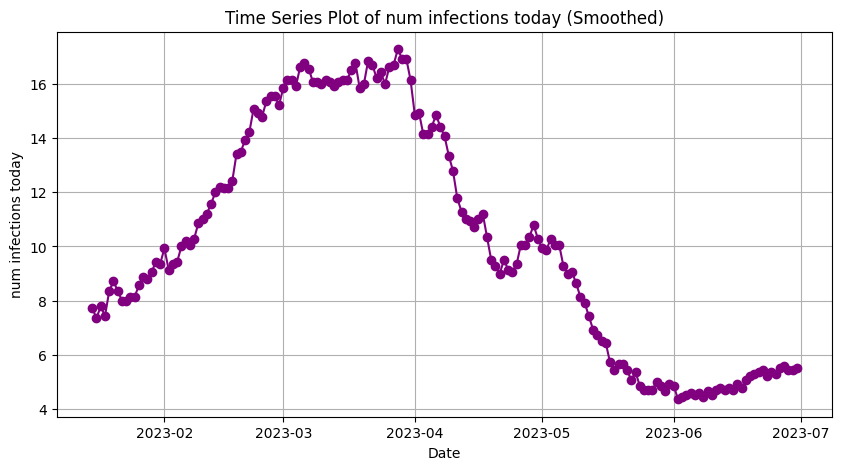

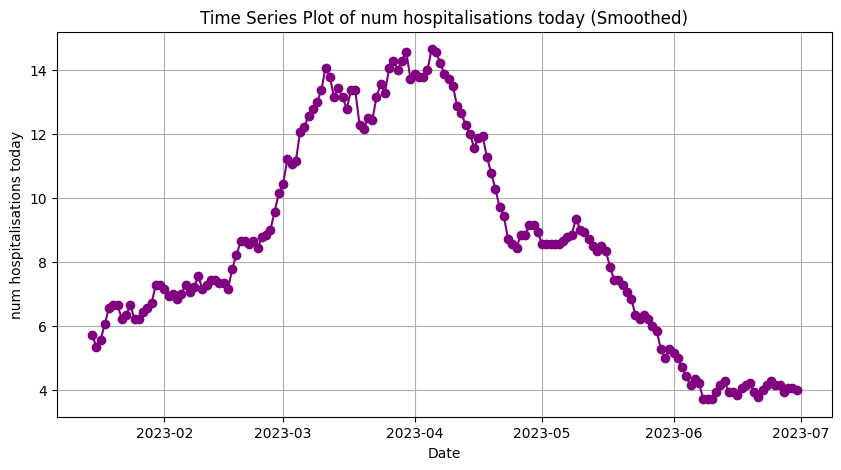

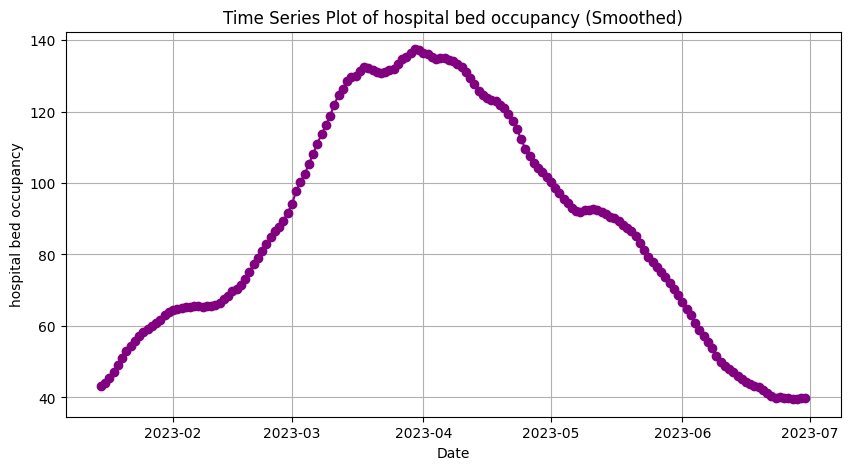

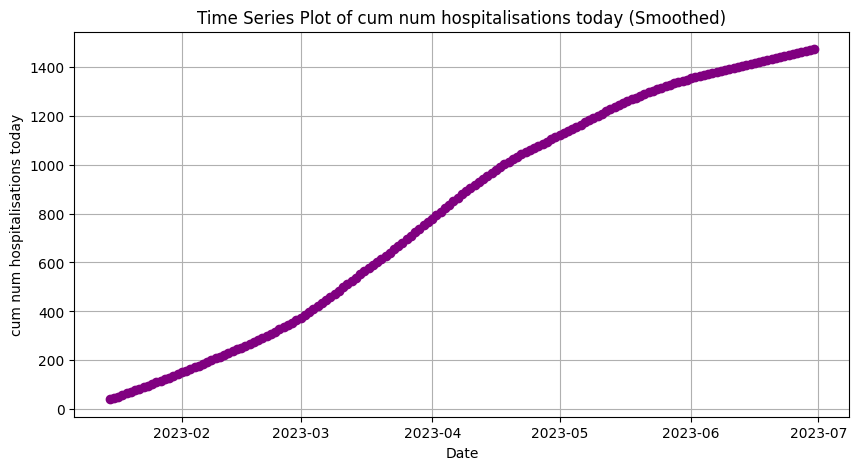

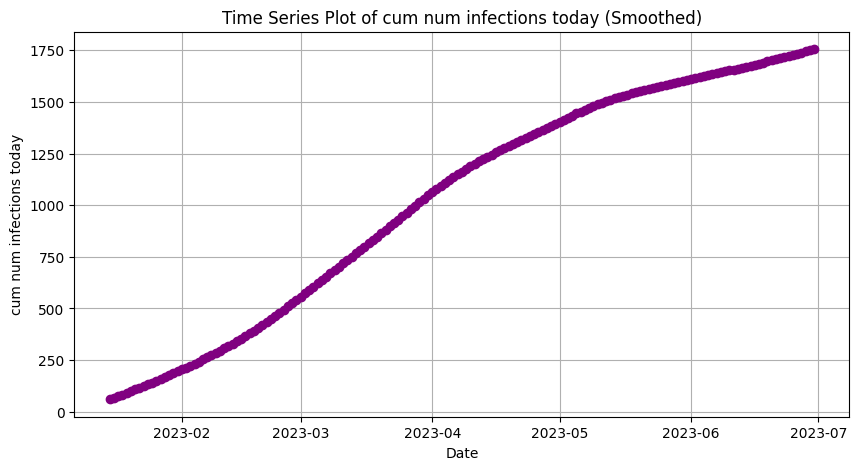

In [ ]:
# Set the window size for the rolling average
window_size = 14  # use a larger window size for more smoothing

# List of numerical columns to plot
numerical_columns = ['susceptible', 'exposed', 'infectious', 'recovered', 'dead',
                     'immune', 'num infections today', 'num hospitalisations today',
                     'hospital bed occupancy', 'cum num hospitalisations today',
                     'cum num infections today']

# Time series plot to show trend for each variable over time, with smoothing applied
for column in numerical_columns:
    plt.figure(figsize=(10, 5))
    # Apply rolling average to smooth the data
    smoothed_data = run1_df[column].rolling(window=window_size).mean()

    plt.plot(run1_df['date'], smoothed_data, marker='o', linestyle='-', color='purple')
    plt.title(f'Time Series Plot of {column} (Smoothed)')
    plt.xlabel('Date')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

EDA Visualization (Multivariate)

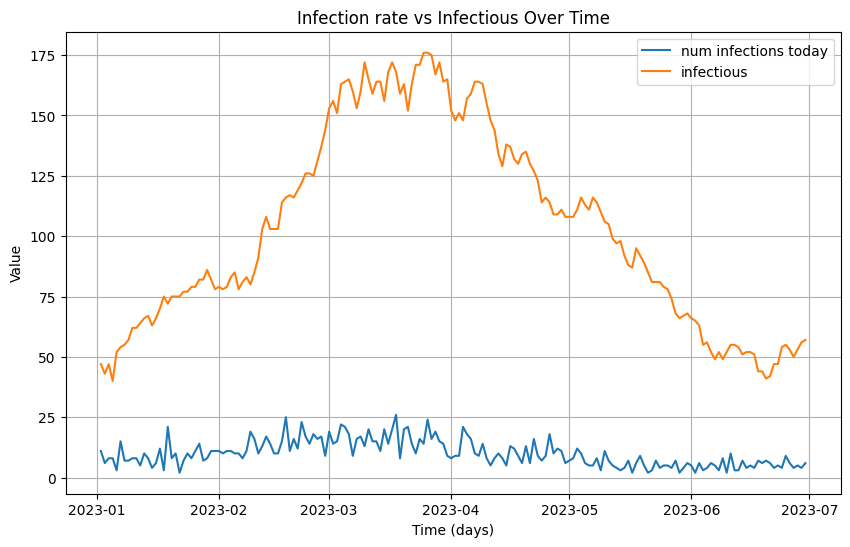

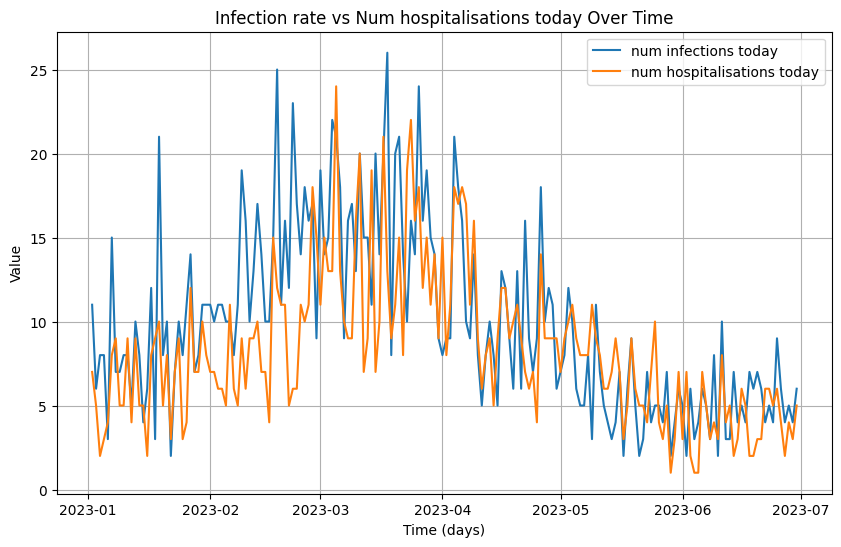

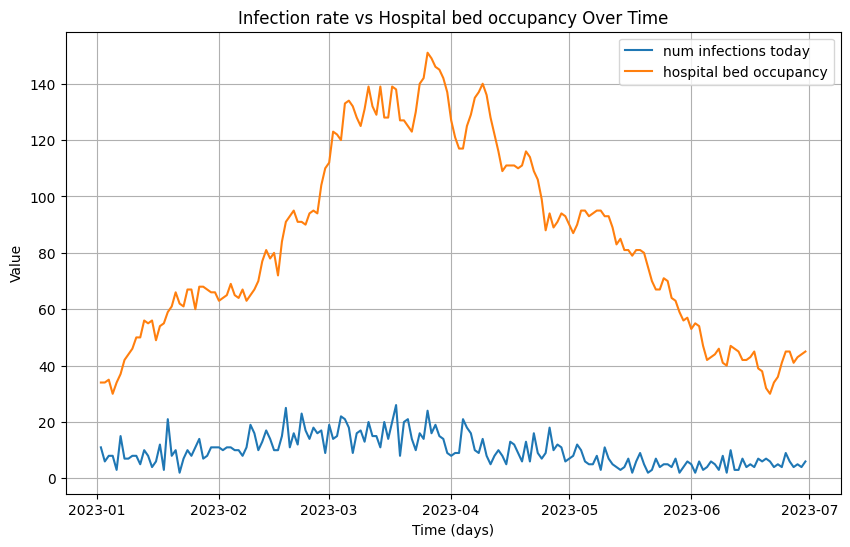

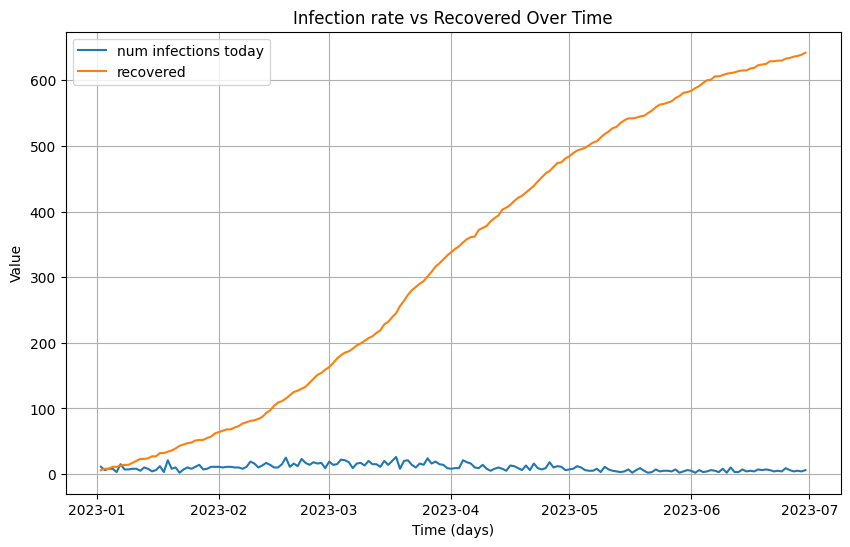

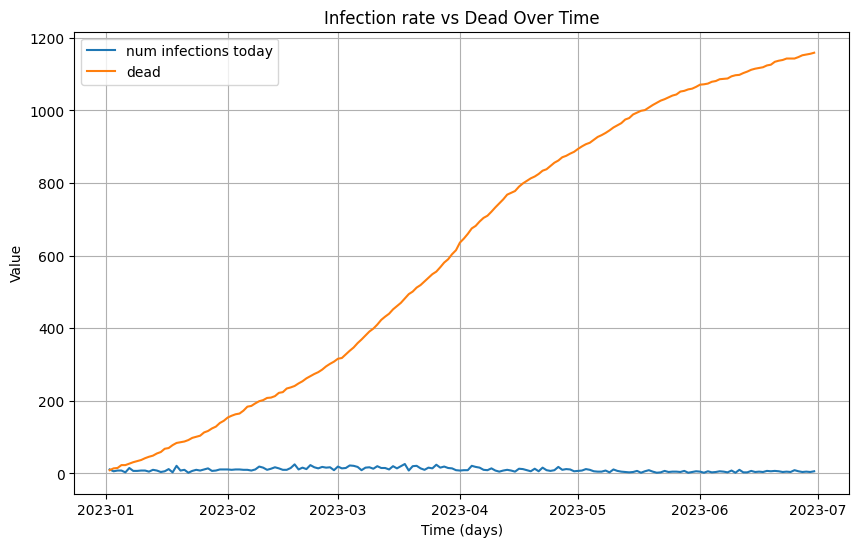

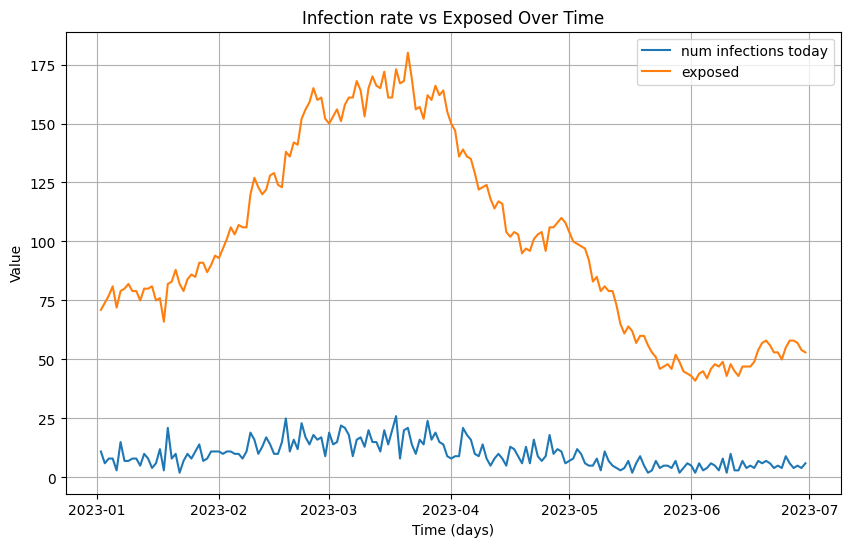

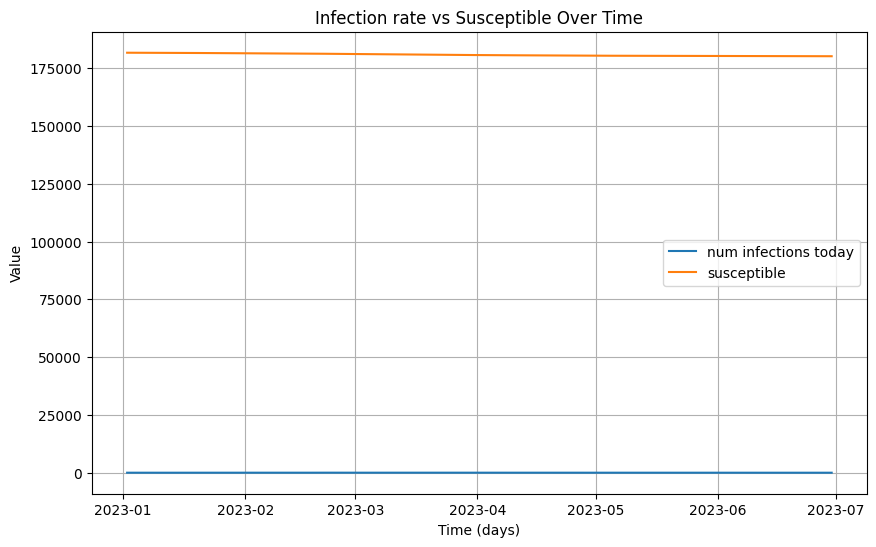

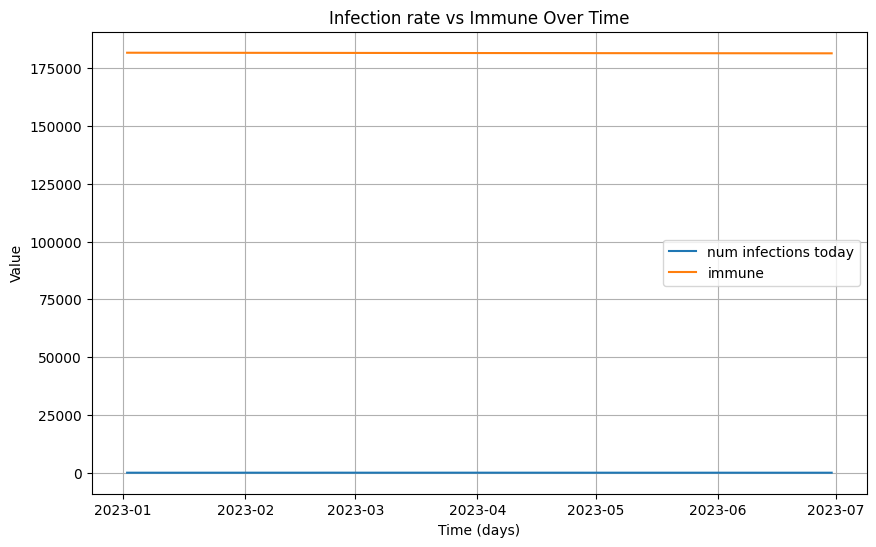

In [ ]:
import matplotlib.pyplot as plt

# Define a function to plot time series for comparison
def plot_comparison(data, target_variable, compare_variable, title):
    plt.figure(figsize=(10, 6))
    plt.plot(data['date'], data[target_variable], label=target_variable)
    plt.plot(data['date'], data[compare_variable], label=compare_variable)
    plt.title(title)
    plt.xlabel('Time (days)')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

# Compare 'num infections today' with all other variables
variables_to_compare = [
    'infectious',
    'num hospitalisations today',
    'hospital bed occupancy',
    'recovered',
    'dead',
    'exposed',
    'susceptible',
    'immune'
]

# Loop through and create plots for each comparison
for variable in variables_to_compare:
    plot_comparison(run1_df, 'num infections today', variable, f'Infection rate vs {variable.capitalize()} Over Time')


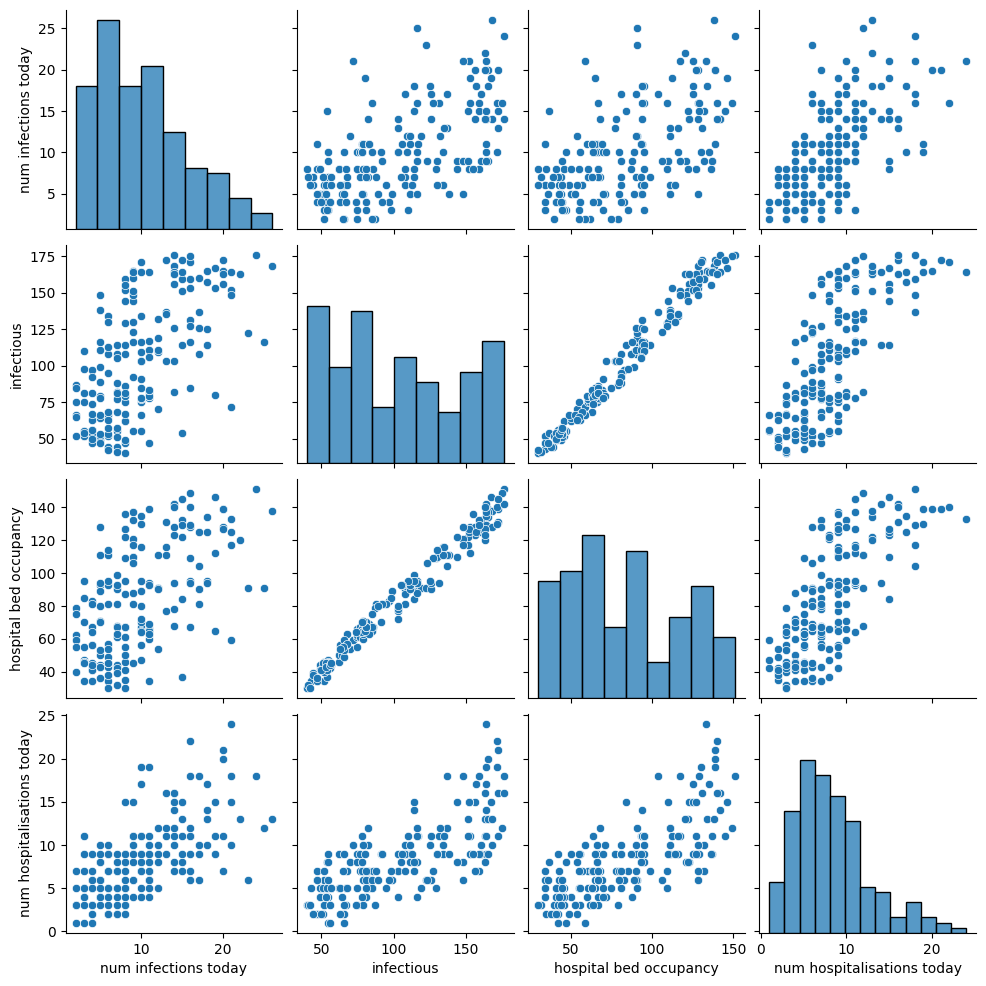

In [ ]:
import seaborn as sns

# Pairplot of selected features including daily infection rate
sns.pairplot(run1_df[['num infections today', 'infectious', 'hospital bed occupancy', 'num hospitalisations today']])
plt.show()

## Initial simple LSTM code

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 - 6s - 100ms/step - loss: 0.0518 - val_loss: 0.0901
Epoch 2/50
60/60 - 0s - 6ms/step - loss: 0.0385 - val_loss: 0.0925
Epoch 3/50
60/60 - 0s - 3ms/step - loss: 0.0360 - val_loss: 0.0914
Epoch 4/50
60/60 - 0s - 5ms/step - loss: 0.0342 - val_loss: 0.0909
Epoch 5/50
60/60 - 0s - 6ms/step - loss: 0.0329 - val_loss: 0.0906
Epoch 6/50
60/60 - 0s - 5ms/step - loss: 0.0319 - val_loss: 0.0906
Epoch 7/50
60/60 - 0s - 5ms/step - loss: 0.0311 - val_loss: 0.0909
Epoch 8/50
60/60 - 0s - 3ms/step - loss: 0.0305 - val_loss: 0.0913
Epoch 9/50
60/60 - 0s - 5ms/step - loss: 0.0301 - val_loss: 0.0918
Epoch 10/50
60/60 - 0s - 3ms/step - loss: 0.0297 - val_loss: 0.0925
Epoch 11/50
60/60 - 0s - 5ms/step - loss: 0.0294 - val_loss: 0.0931
Epoch 12/50
60/60 - 0s - 3ms/step - loss: 0.0292 - val_loss: 0.0938
Epoch 13/50
60/60 - 0s - 4ms/step - loss: 0.0290 - val_loss: 0.0943
Epoch 14/50
60/60 - 0s - 5ms/step - loss: 0.0289 - val_loss: 0.0949
Epoch 15/50
60/60 - 0s - 5ms/step - loss: 0.0287 - val_loss: 0.095

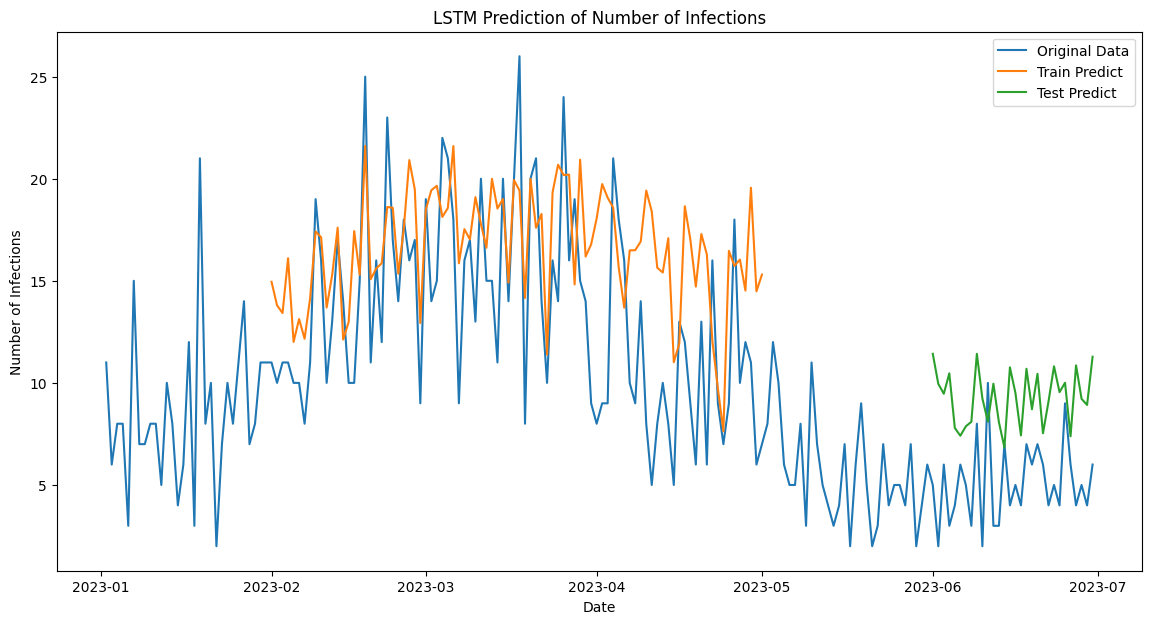

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━

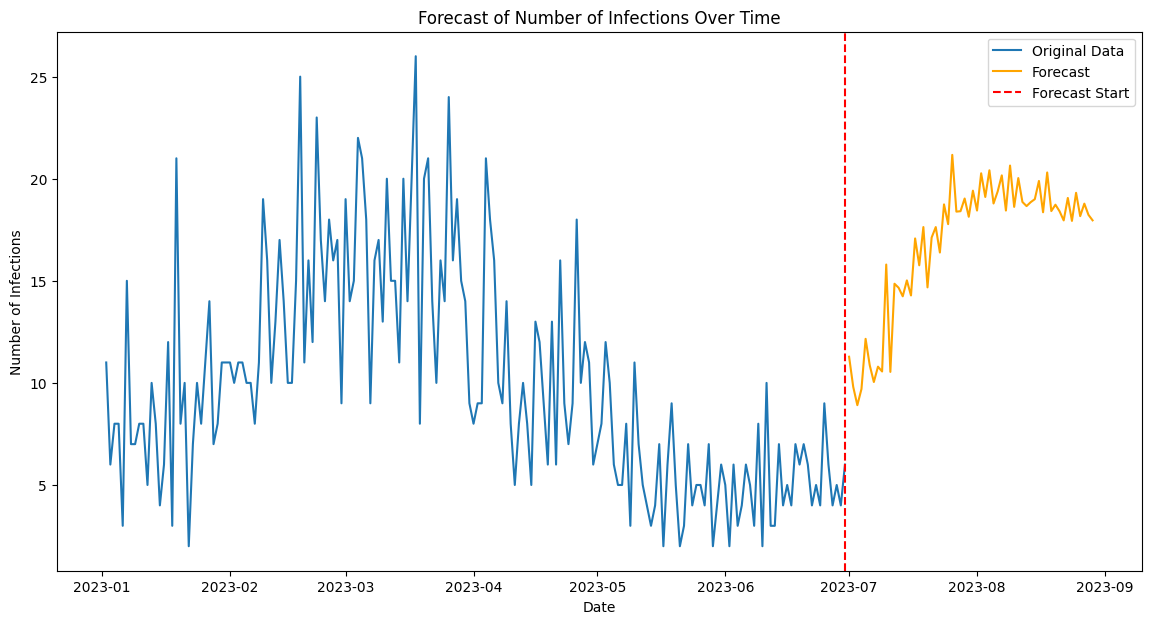

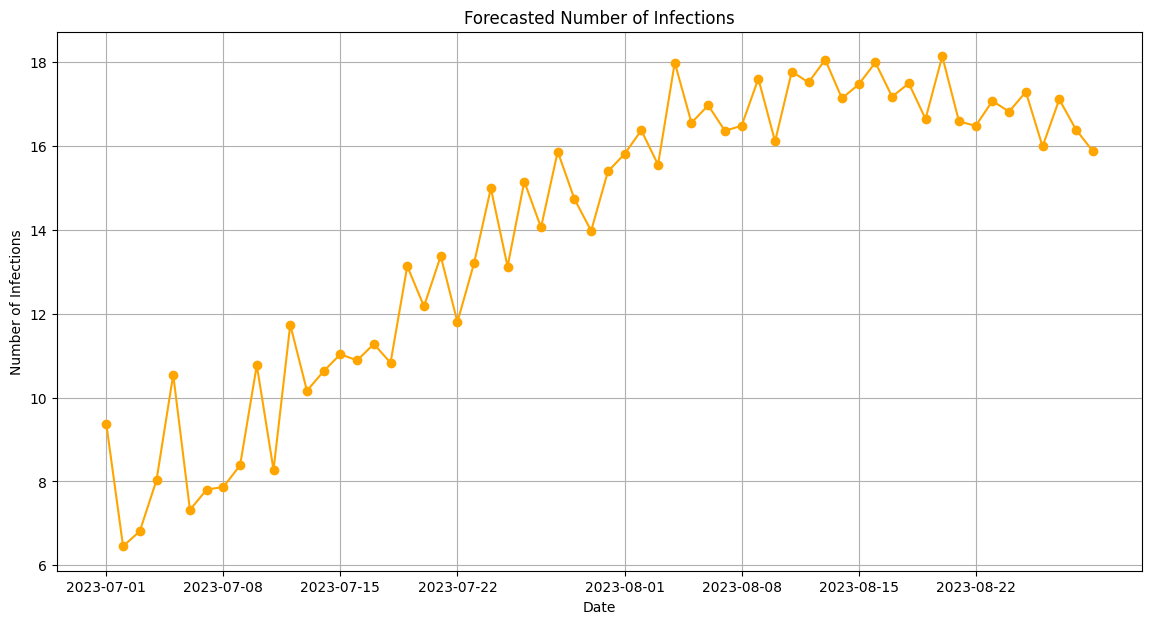

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

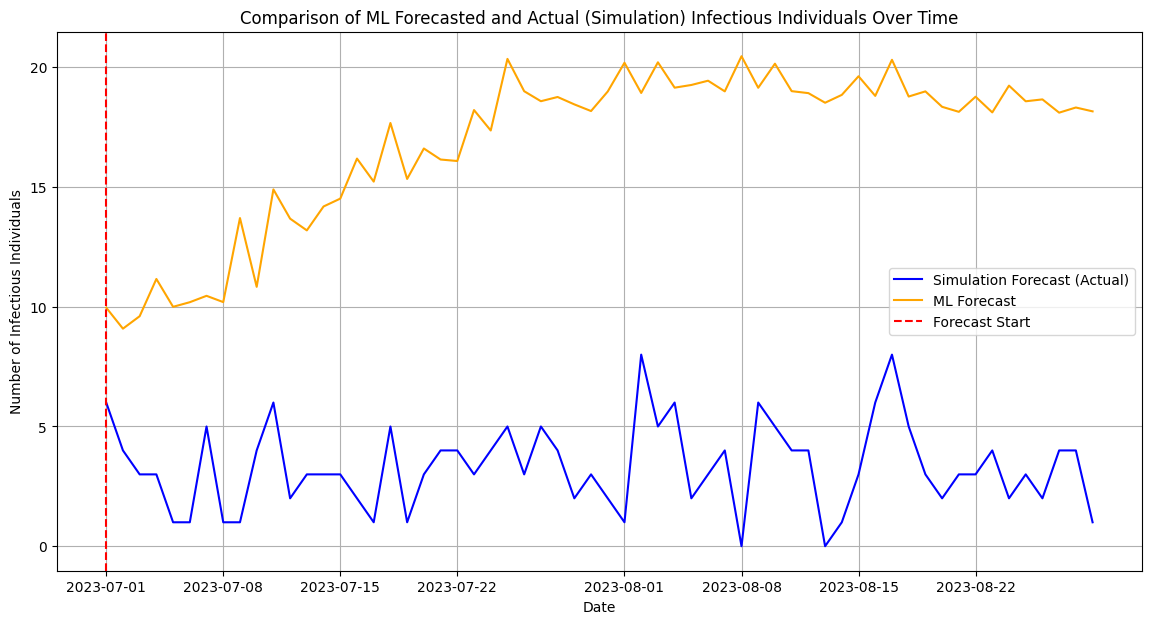

Mean Squared Error between Simulation and ML Forecast: 194.52


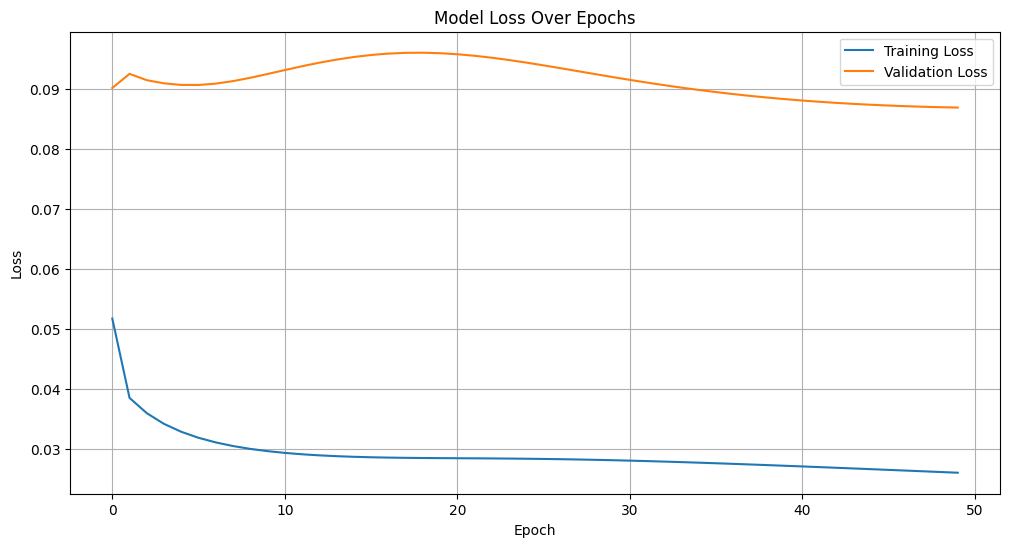

In [ ]:

# Step 1: Load the data from the ZIP file
with zipfile.ZipFile('/run1.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run1_extracted')
    csv_file_path = '/content/run1_extracted/run1/klaipeda-measures_lt.csv'
    run1_df = pd.read_csv(csv_file_path)

# Step 2: Convert the 'date' column to datetime format and set it as the index
run1_df['date'] = pd.to_datetime(run1_df['date'], dayfirst=True)
run1_df.set_index('date', inplace=True)

# Step 3: Select the "num infections today" column and convert it to float32
dataset = run1_df[['num infections today']].values.astype('float32')

# Step 4: Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# Step 5: Convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# Step 6: Fix random seed for reproducibility
tf.random.set_seed(7)

# Step 7: Split the dataset into training and testing sets
look_back = 30  # Using 30 time steps
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size, :], dataset[train_size:len(dataset), :]

# Step 8: Reshape the dataset into X=t and Y=t+1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

# Step 9: Reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

# Step 10: Create and fit the LSTM network
model = Sequential()
model.add(LSTM(50, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(trainX, trainY, epochs=50, batch_size=1, verbose=2, validation_split=0.33) # Added validation_split argument

# Step 11: Make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# Step 12: Inverse transform the predictions to the original scale
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])

# Step 13: Calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:, 0]))
print(f'Train Score: {trainScore:.2f} RMSE')
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:, 0]))
print(f'Test Score: {testScore:.2f} RMSE')

# Step 14: Shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict) + look_back, :] = trainPredict

# Step 15: Shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict) + (look_back * 2):len(dataset), :] = testPredict

# Step 16: Plot baseline and predictions
plt.figure(figsize=(14, 7))
plt.plot(run1_df.index, scaler.inverse_transform(dataset), label='Original Data')
plt.plot(run1_df.index, trainPredictPlot, label='Train Predict')
plt.plot(run1_df.index, testPredictPlot, label='Test Predict')
plt.title('LSTM Prediction of Number of Infections')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.legend()
plt.show()

# Step 17: Forecast future values
future_days = 60  # Forecasting for the next 60 days
last_sequence = testX[-1]  # Start with the last sequence of the test set
future_predictions = []

for _ in range(future_days):
    last_sequence = last_sequence.reshape((1, 1, look_back))
    predicted_value = model.predict(last_sequence)
    future_predictions.append(predicted_value[0, 0])

    new_sequence = np.append(last_sequence[:, :, 1:], predicted_value)
    last_sequence = new_sequence.reshape(1, 1, look_back)

# Inverse transform the predictions to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Step 18: Create a DataFrame for the forecasted data
last_date = run1_df.index[-1]
last_date = pd.to_datetime(last_date)  # Ensure last_date is a datetime object
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
forecast_df = pd.DataFrame({'date': forecast_dates, 'forecasted_num_infections': future_predictions.flatten()})

# Step 20: Save the forecast data
forecast_df.to_csv('/content/forecasted_infections.csv', index=False)

# Step 19: Plot Forecast vs Actual Data
plt.figure(figsize=(14, 7))
plt.plot(run1_df.index, scaler.inverse_transform(dataset), label='Original Data')
plt.plot(forecast_df['date'], forecast_df['forecasted_num_infections'], label='Forecast', color='orange')
plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('Forecast of Number of Infections Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.legend()
plt.show()

# Step 20: Save the forecast data
forecast_df.to_csv('/content/forecasted_infections.csv', index=False)

# Individual forcasted data

# Prepare the forecast data
forecast_data = {
    "date": [
        "01/07/2023", "02/07/2023", "03/07/2023", "04/07/2023", "05/07/2023",
        "06/07/2023", "07/07/2023", "08/07/2023", "09/07/2023", "10/07/2023",
        "11/07/2023", "12/07/2023", "13/07/2023", "14/07/2023", "15/07/2023",
        "16/07/2023", "17/07/2023", "18/07/2023", "19/07/2023", "20/07/2023",
        "21/07/2023", "22/07/2023", "23/07/2023", "24/07/2023", "25/07/2023",
        "26/07/2023", "27/07/2023", "28/07/2023", "29/07/2023", "30/07/2023",
        "31/07/2023", "01/08/2023", "02/08/2023", "03/08/2023", "04/08/2023",
        "05/08/2023", "06/08/2023", "07/08/2023", "08/08/2023", "09/08/2023",
        "10/08/2023", "11/08/2023", "12/08/2023", "13/08/2023", "14/08/2023",
        "15/08/2023", "16/08/2023", "17/08/2023", "18/08/2023", "19/08/2023",
        "20/08/2023", "21/08/2023", "22/08/2023", "23/08/2023", "24/08/2023",
        "25/08/2023", "26/08/2023", "27/08/2023", "28/08/2023", "29/08/2023"
    ],
    "forecasted_num_infections": [
        9.364071, 6.455828, 6.8130145, 8.029357, 10.548178,
        7.32317, 7.8066034, 7.8698573, 8.386822, 10.774851,
        8.276994, 11.738129, 10.164104, 10.631995, 11.037461,
        10.888684, 11.279948, 10.832801, 13.137, 12.17793,
        13.378281, 11.8042145, 13.215778, 14.995809, 13.128406,
        15.156784, 14.061047, 15.870318, 14.737811, 13.980922,
        15.395821, 15.814825, 16.377375, 15.558598, 17.992447,
        16.557343, 16.973946, 16.36598, 16.487232, 17.609476,
        16.11568, 17.781387, 17.520103, 18.063005, 17.141352,
        17.472462, 17.996397, 17.180552, 17.49928, 16.649954,
        18.145895, 16.5928, 16.484053, 17.078484, 16.824366,
        17.296785, 15.993339, 17.11504, 16.394697, 15.884266
    ]
}

# Convert forecast data to DataFrame
forecast_df = pd.DataFrame(forecast_data)
forecast_df['date'] = pd.to_datetime(forecast_df['date'], format='%d/%m/%Y')

# Plot the forecasted data
plt.figure(figsize=(14, 7))
plt.plot(forecast_df['date'], forecast_df['forecasted_num_infections'], marker='o', color='orange')

# Adding labels, title, and legend
plt.title('Forecasted Number of Infections')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.grid(True)
plt.show()

# comparison of the forecasts
# Forecast future values
def forecast_lstm(model, data, look_back, n_future):
    forecasted = []
    input_seq = data[-look_back:].reshape(1, 1, look_back)
    for _ in range(n_future):
        next_value = model.predict(input_seq)
        forecasted.append(next_value[0, 0])
        input_seq = np.append(input_seq[:, :, 1:], next_value).reshape(1, 1, look_back)
    return np.array(forecasted).reshape(-1, 1)

forecast_days = 60
forecast = forecast_lstm(model, dataset, look_back, forecast_days)

# Invert the forecast to original scale
forecast = scaler.inverse_transform(forecast)

# Step 4: Load the simulation forecast data from run2.zip
with zipfile.ZipFile('/run2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run2_extracted')
    simulation_csv_file_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
    simulation_df = pd.read_csv(simulation_csv_file_path)

# Convert 'date' column to datetime and filter data starting from July 1, 2023
simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
simulation_forecast_start_date = pd.to_datetime('2023-07-01')
simulation_df = simulation_df[simulation_df['date'] >= simulation_forecast_start_date]
simulation_df = simulation_df.head(forecast_days)

# Create a DataFrame to hold the comparison
forecast_dates = pd.date_range(start=simulation_forecast_start_date, periods=forecast_days)
comparison_df = pd.DataFrame({
    'date': forecast_dates,
    'simulation_forecast': simulation_df['num infections today'].values,
    'ml_forecast': forecast.flatten()
})

# Plot both forecasts for comparison
plt.figure(figsize=(14, 7))
plt.plot(comparison_df['date'], comparison_df['simulation_forecast'], label='Simulation Forecast (Actual)', color='blue')
plt.plot(comparison_df['date'], comparison_df['ml_forecast'], label='ML Forecast', color='orange')
plt.axvline(pd.to_datetime('2023-07-01'), color='red', linestyle='--', label='Forecast Start')
plt.xlabel('Date')
plt.ylabel('Number of Infectious Individuals')
plt.title('Comparison of ML Forecasted and Actual (Simulation) Infectious Individuals Over Time')
plt.grid(True)
plt.legend()
plt.show()

# Calculate and print Mean Squared Error (MSE) between the two forecasts
mse = mean_squared_error(comparison_df['simulation_forecast'], comparison_df['ml_forecast'])
print(f'Mean Squared Error between Simulation and ML Forecast: {mse:.2f}')

# Output the comparison DataFrame
comparison_df.head()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss') # This line should now work without error.
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Stacked LSTM

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 - 11s - 6s/step - loss: 0.1352 - mae: 0.3020 - val_loss: 0.0314 - val_mae: 0.1385
Epoch 2/50
2/2 - 1s - 405ms/step - loss: 0.1130 - mae: 0.2683 - val_loss: 0.0278 - val_mae: 0.1290
Epoch 3/50
2/2 - 0s - 167ms/step - loss: 0.0973 - mae: 0.2419 - val_loss: 0.0273 - val_mae: 0.1313
Epoch 4/50
2/2 - 0s - 110ms/step - loss: 0.0822 - mae: 0.2188 - val_loss: 0.0289 - val_mae: 0.1372
Epoch 5/50
2/2 - 0s - 105ms/step - loss: 0.0710 - mae: 0.2034 - val_loss: 0.0301 - val_mae: 0.1416
Epoch 6/50
2/2 - 0s - 109ms/step - loss: 0.0625 - mae: 0.1927 - val_loss: 0.0293 - val_mae: 0.1396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 
Train RMSE: 0.29, Test RMSE: 0.17


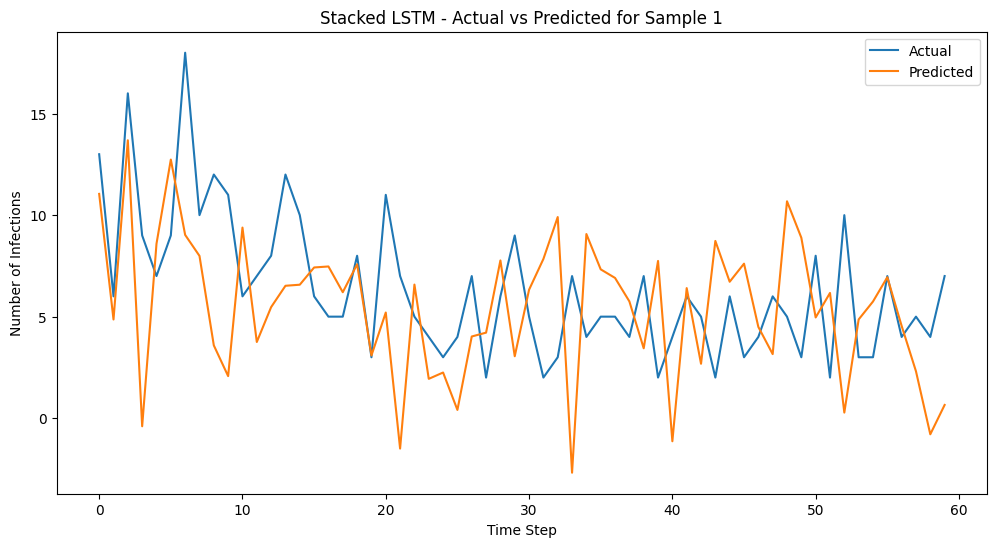

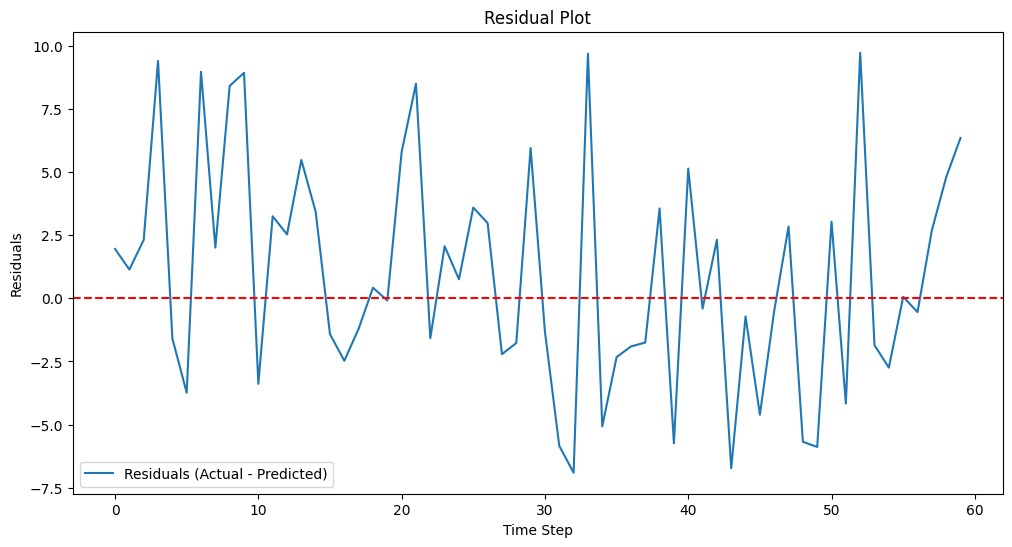

In [ ]:
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Load and Preprocess Data (both actual and simulation data)
with zipfile.ZipFile('/run1.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run1_extracted')
    csv_file_path = '/content/run1_extracted/run1/klaipeda-measures_lt.csv'
    run1_df = pd.read_csv(csv_file_path)

run1_df['date'] = pd.to_datetime(run1_df['date'], dayfirst=True)
run1_df.set_index('date', inplace=True)

# Load the simulation forecast from run2.zip for comparison
with zipfile.ZipFile('/run2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run2_extracted')
    simulation_csv_file_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
    simulation_df = pd.read_csv(simulation_csv_file_path)

simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
simulation_forecast_start_date = pd.to_datetime('2023-07-01')
simulation_df = simulation_df[simulation_df['date'] >= simulation_forecast_start_date]
simulation_df = simulation_df.head(60)  # Assuming the same forecast horizon

# Step 2: Selecting relevant features
features = ['num infections today', 'infectious', 'hospital bed occupancy', 'num hospitalisations today']
target = 'num infections today'

# Step 3: Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(run1_df[features])

# Step 4: Create sequences for time series forecasting
def create_sequences(data, look_back, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - look_back - forecast_horizon + 1):
        X.append(data[i:(i + look_back), :])
        y.append(data[(i + look_back):(i + look_back + forecast_horizon), 0])  # Predict future infections
    return np.array(X), np.array(y)

look_back = 60  # Number of past days used for prediction
forecast_horizon = 60  # Forecast horizon (number of days to predict)
X, y = create_sequences(scaled_data, look_back, forecast_horizon)

# Step 5: Split the data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Step 6: Build the Stacked LSTM Model
def build_stacked_lstm(look_back, n_features, forecast_horizon):
    model = Sequential()
    model.add(LSTM(120, return_sequences=True, input_shape=(look_back, n_features)))
    model.add(Dropout(0.3))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(forecast_horizon))  # Output forecast_horizon days ahead
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

n_features = X_train.shape[2]
stacked_lstm_model = build_stacked_lstm(look_back, n_features, forecast_horizon)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Step 7: Train the Stacked LSTM Model
history = stacked_lstm_model.fit(X_train, y_train, epochs=50, batch_size=36, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=2)

# Step 8: Make Predictions and Evaluate
y_pred = stacked_lstm_model.predict(X_test)

# Step 9: Rescale predictions to original scale
def rescale_predictions(y_pred, y_test, scaler, forecast_horizon, n_features):
    y_pred_rescaled, y_test_rescaled = [], []
    for i in range(len(y_pred)):
        pred_sequence = np.zeros((forecast_horizon, n_features))
        test_sequence = np.zeros((forecast_horizon, n_features))
        pred_sequence[:, 0] = y_pred[i]  # Prediction for 'num infections today'
        test_sequence[:, 0] = y_test[i]  # True value for 'num infections today'
        y_pred_rescaled.append(scaler.inverse_transform(pred_sequence)[:, 0])
        y_test_rescaled.append(scaler.inverse_transform(test_sequence)[:, 0])
    return y_pred_rescaled, y_test_rescaled

y_pred_rescaled, y_test_rescaled = rescale_predictions(y_pred, y_test, scaler, forecast_horizon, n_features)

# Step 10: Calculate RMSE and MAPE for Test and Train Data
train_pred = stacked_lstm_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train.flatten(), train_pred.flatten()))
test_rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))

# Print the error metrics
print(f"Train RMSE: {train_rmse:.2f}, Test RMSE: {test_rmse:.2f}")


# Step 11: Plot the predictions of the model and the actual data to assess model performance.
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[0], label='Actual')
plt.plot(y_pred_rescaled[0], label='Predicted')
plt.title('Stacked LSTM - Actual vs Predicted for Sample 1')
plt.xlabel('Time Step')
plt.ylabel('Number of Infections')
plt.legend()
plt.show()

# Step 12: Plot the residuals
residuals = np.array(y_test_rescaled[0]) - np.array(y_pred_rescaled[0])
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals (Actual - Predicted)')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Time Step')
plt.ylabel('Residuals')
plt.legend()
plt.show()


# Step 19: Create a DataFrame for the forecasted data
stacked_forecast_df = pd.DataFrame({'forecasted_num_infections': y_pred_rescaled[0]}) # Create a DataFrame named stacked_forecast_df

# Step 20: Save the forecast data
stacked_forecast_df.to_csv('/content/stacked_forecasted_infections.csv', index=False)

###Forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


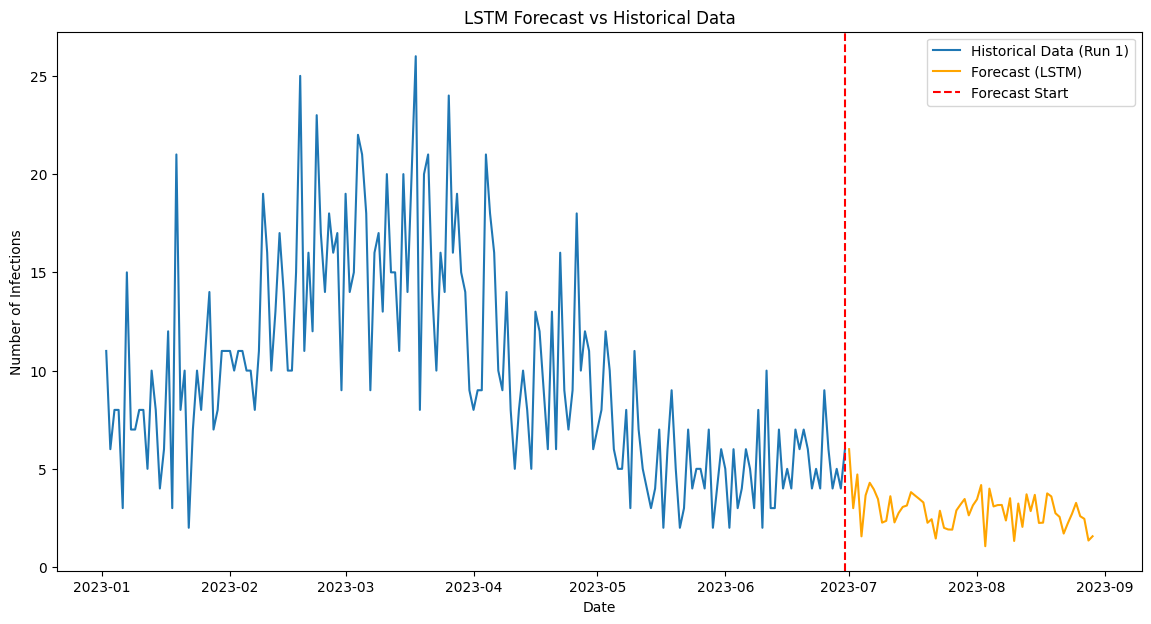

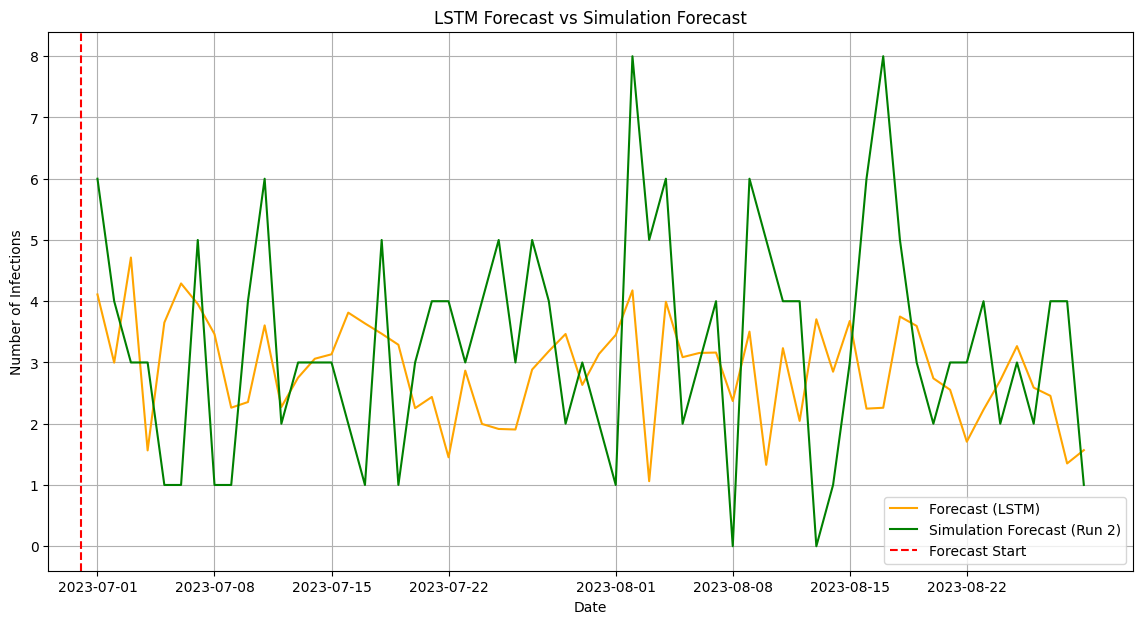

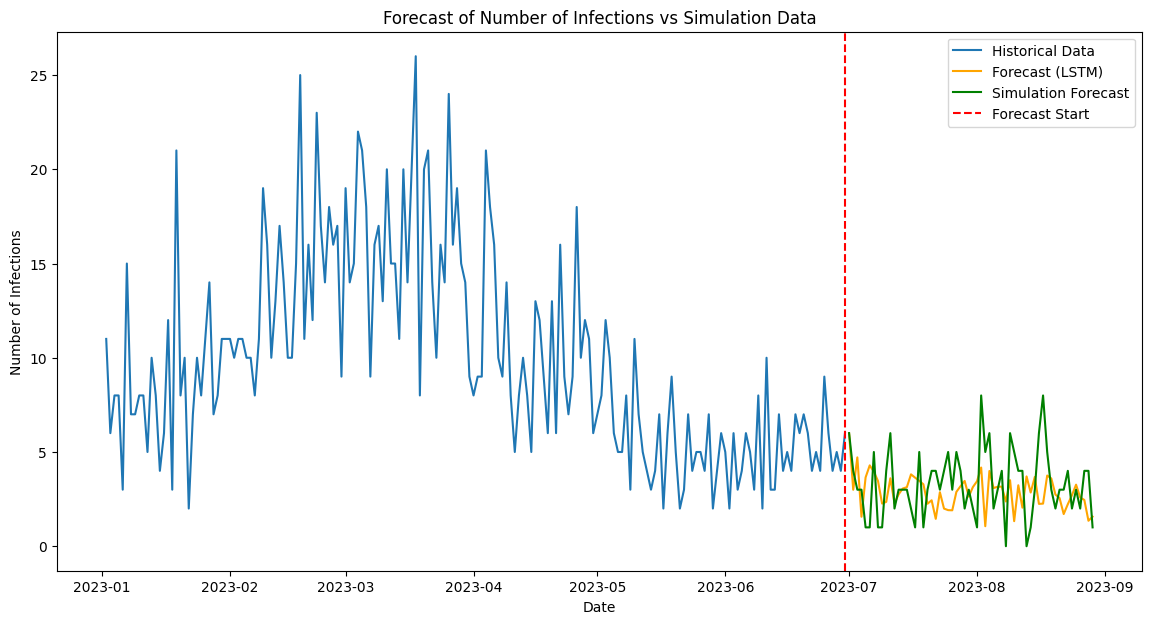

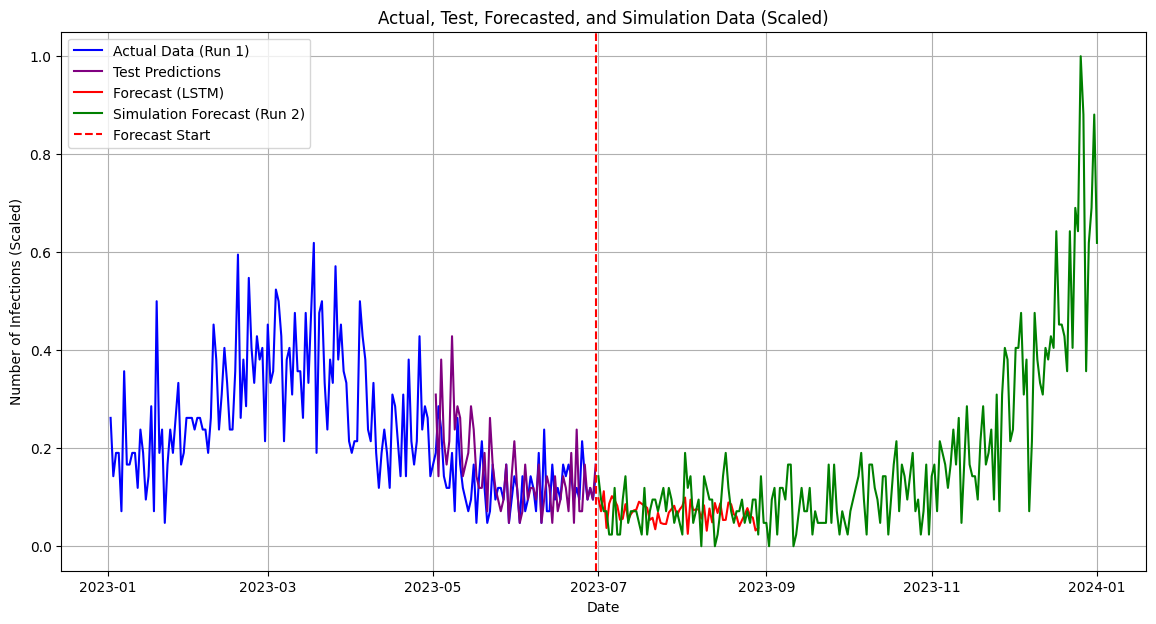

In [ ]:
# Forecast future values using the last sequence
last_sequence = scaled_data[-look_back:]  # Get the last 60 days (May and June)
last_sequence = last_sequence.reshape((1, look_back, n_features))

# Predict the next 60 days (July to September)
future_predictions_scaled = stacked_lstm_model.predict(last_sequence)

# Inverse transform forecasted values to the original scale
future_sequence = np.zeros((forecast_horizon, n_features))
future_sequence[:, 0] = future_predictions_scaled[0]  # Only forecast the target feature
future_predictions = scaler.inverse_transform(future_sequence)[:, 0]

# Create a DataFrame for forecasted data (July to September)
last_date = run1_df.index[-1]  # Last date from the historical data (June 30)
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon)
forecast_df = pd.DataFrame({'date': forecast_dates, 'forecasted_num_infections': future_predictions})

# Plot LSTM Forecast vs Historical Data (Run 1)
plt.figure(figsize=(14, 7))
plt.plot(run1_df.index, run1_df[target], label='Historical Data (Run 1)')
plt.plot(forecast_df['date'], [run1_df[target].iloc[-1]] + list(forecast_df['forecasted_num_infections'][1:]),
         label='Forecast (LSTM)', color='orange')
plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('LSTM Forecast vs Historical Data')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.legend()
plt.show()

# Plot LSTM Forecast vs Simulation Forecast (Run 2)
with zipfile.ZipFile('/run2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run2_extracted')
    simulation_csv_file_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
    simulation_df = pd.read_csv(simulation_csv_file_path)

simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
simulation_forecast_start_date = pd.to_datetime('2023-07-01')
simulation_df = simulation_df[simulation_df['date'] >= simulation_forecast_start_date]
simulation_df = simulation_df.head(forecast_horizon)

# Plot LSTM vs Simulation Forecast
plt.figure(figsize=(14, 7))
plt.plot(forecast_df['date'], forecast_df['forecasted_num_infections'], label='Forecast (LSTM)', color='orange')
plt.plot(simulation_df['date'], simulation_df[target], label='Simulation Forecast (Run 2)', color='green')
plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('LSTM Forecast vs Simulation Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.legend()
plt.grid(True)
plt.show()

# Step 10: Plot forecasted values and simulation forecast for comparison
plt.figure(figsize=(14, 7))
plt.plot(run1_df.index, run1_df[target], label='Historical Data')
plt.plot(forecast_df['date'], [run1_df[target].iloc[-1]] + list(forecast_df['forecasted_num_infections'][1:]),
         label='Forecast (LSTM)', color='orange')
plt.plot(simulation_df['date'], simulation_df[target], label='Simulation Forecast', color='green')

plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('Forecast of Number of Infections vs Simulation Data')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.legend()
plt.show()


# Create a DataFrame for forecasted data
last_date = run1_df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon)
forecast_df = pd.DataFrame({'date': forecast_dates, 'forecasted_num_infections': future_predictions})

# Combine actual, predicted (test), forecasted, and simulation values into a single DataFrame for scaling
combined_df = pd.concat([
    run1_df[['num infections today']],
    pd.DataFrame({'num infections today': y_test_rescaled[0]}, index=run1_df.index[-len(y_test_rescaled[0]):]),  # Test data
    forecast_df[['forecasted_num_infections']].rename(columns={'forecasted_num_infections': 'num infections today'}),
    run2_df[['num infections today']][run2_df['date'] >= last_date + pd.Timedelta(days=1)]  # Simulation data
], axis=0)

# Normalize the combined DataFrame
scaler = MinMaxScaler()
combined_df['num infections today'] = scaler.fit_transform(combined_df[['num infections today']])

# Separate the scaled data back into actual, predicted, forecasted, and simulation
scaled_actual = combined_df['num infections today'][:len(run1_df)]
scaled_test = combined_df['num infections today'][len(run1_df):len(run1_df) + len(y_test_rescaled[0])]
scaled_forecast = combined_df['num infections today'][len(run1_df) + len(y_test_rescaled[0]):-len(run2_df[run2_df['date'] >= last_date + pd.Timedelta(days=1)])]
scaled_simulation = combined_df['num infections today'][-len(run2_df[run2_df['date'] >= last_date + pd.Timedelta(days=1)]):]

# Plot the scaled data
plt.figure(figsize=(14, 7))
plt.plot(run1_df.index, scaled_actual, label='Actual Data (Run 1)', color='blue')
plt.plot(run1_df.index[-len(y_test_rescaled[0]):], scaled_test, label='Test Predictions', color='purple')
plt.plot(forecast_df['date'], scaled_forecast, label='Forecast (LSTM)', color='red')
plt.plot(run2_df['date'][run2_df['date'] >= last_date + pd.Timedelta(days=1)], scaled_simulation, label='Simulation Forecast (Run 2)', color='green')

plt.axvline(x=last_date, color='red', linestyle='--', label='Forecast Start')
plt.title('Actual, Test, Forecasted, and Simulation Data (Scaled)')
plt.xlabel('Date')
plt.ylabel('Number of Infections (Scaled)')
plt.legend()
plt.grid(True)

#Prophet Model

DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/2tsnq6ts.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/79816dvt.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33477', 'data', 'file=/tmp/tmp9g28p825/2tsnq6ts.json', 'init=/tmp/tmp9g28p825/79816dvt.json', 'output', 'file=/tmp/tmp9g28p825/prophet_modelafccgv1y/prophet_model-20240920165806.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:58:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:58:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


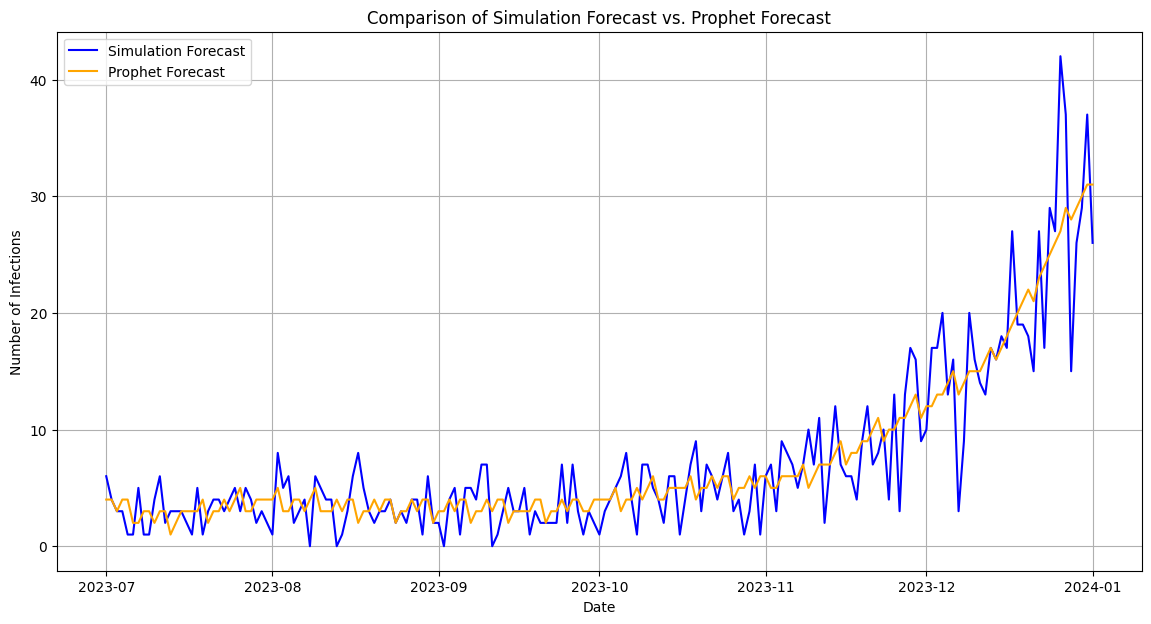

/usr/local/lib/python3.10/dist-packages/prophet/plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


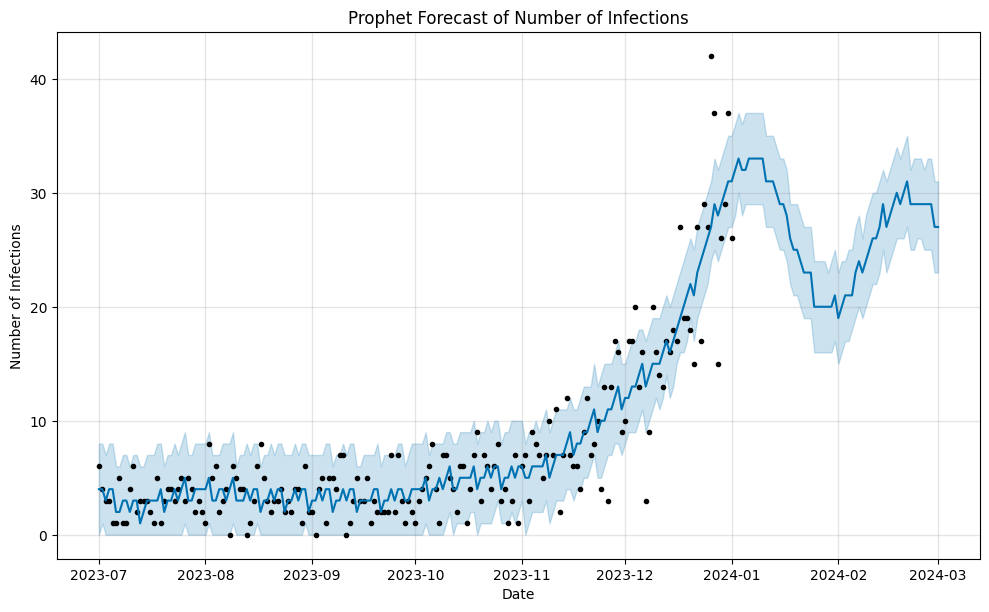

            ds  yhat  yhat_lower  yhat_upper
235 2024-02-21    31          27          35
236 2024-02-22    29          25          32
237 2024-02-23    29          25          33
238 2024-02-24    29          26          33
239 2024-02-25    29          26          33
240 2024-02-26    29          25          32
241 2024-02-27    29          25          33
242 2024-02-28    29          25          33
243 2024-02-29    27          23          31
244 2024-03-01    27          23          31


In [ ]:
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# Step 1: Extract and Load Simulation Forecast Data from run2.zip
with zipfile.ZipFile('/run2.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/run2_extracted')
    csv_file_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
    run2_df = pd.read_csv(csv_file_path)

# Convert 'date' column to datetime
run2_df['date'] = pd.to_datetime(run2_df['date'], dayfirst=True)

# Filter data starting from July 2023 onwards
simulation_forecast_df = run2_df[run2_df['date'] >= '2023-07-01']
simulation_forecast_df = simulation_forecast_df[['date', 'num infections today']]
simulation_forecast_df.rename(columns={'date': 'ds', 'num infections today': 'simulation_forecast'}, inplace=True)

# Step 2: Load and Prepare the Original Data for Prophet Model
run1_df = simulation_forecast_df.copy()  # Assuming you're working with similar data
run1_df.rename(columns={'ds': 'ds', 'simulation_forecast': 'y'}, inplace=True)

# Step 3: Initialize and Train the Prophet Model
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(run1_df[['ds', 'y']])

# Step 4: Create Future Dates and Predict
future_dates = model.make_future_dataframe(periods=60)
forecast = model.predict(future_dates)

# Step 5: Apply Post-Processing and Round Forecast Values
forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))
forecast['yhat_lower'] = forecast['yhat_lower'].apply(lambda x: max(round(x), 0))
forecast['yhat_upper'] = forecast['yhat_upper'].apply(lambda x: max(round(x), 0))

# Step 6: Align Simulation Forecast with Prophet Forecast
comparison_df = pd.merge(simulation_forecast_df, forecast[['ds', 'yhat']], on='ds', how='inner')
comparison_df.rename(columns={'yhat': 'prophet_forecast'}, inplace=True)

# Step 7: Plot the Comparison
plt.figure(figsize=(14, 7))
plt.plot(comparison_df['ds'], comparison_df['simulation_forecast'], label='Simulation Forecast', color='blue')
plt.plot(comparison_df['ds'], comparison_df['prophet_forecast'], label='Prophet Forecast', color='orange')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.title('Comparison of Simulation Forecast vs. Prophet Forecast')
plt.legend()
plt.grid(True)
plt.show()


# Round the predictions and ensure non-negative values
forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))
forecast['yhat_lower'] = forecast['yhat_lower'].apply(lambda x: max(round(x), 0))
forecast['yhat_upper'] = forecast['yhat_upper'].apply(lambda x: max(round(x), 0))

# Plot the forecast
model.plot(forecast)
plt.title('Prophet Forecast of Number of Infections')
plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.show()

# Display the last 10 predictions
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))




#SARIMA Model

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Test RMSE: 2.4120411109169453


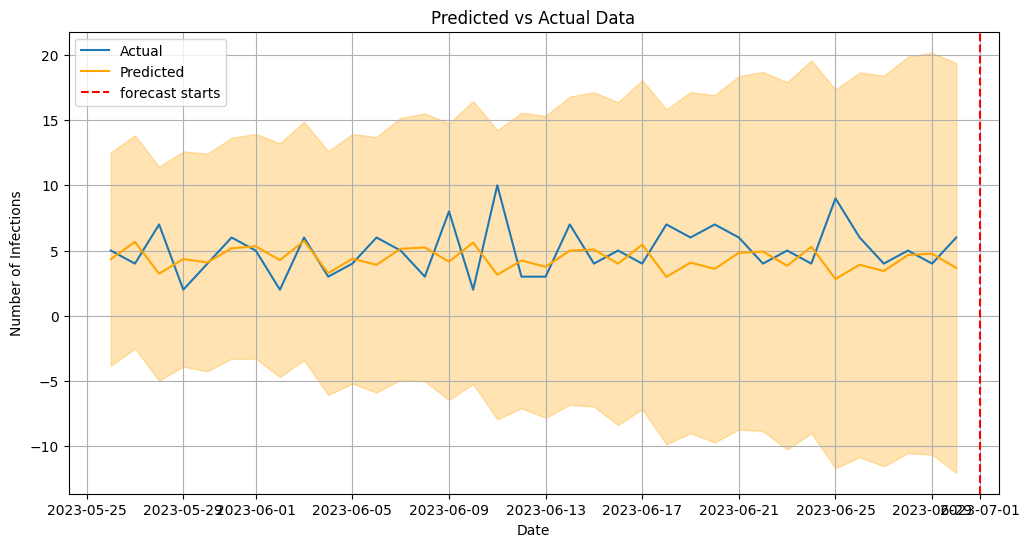

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


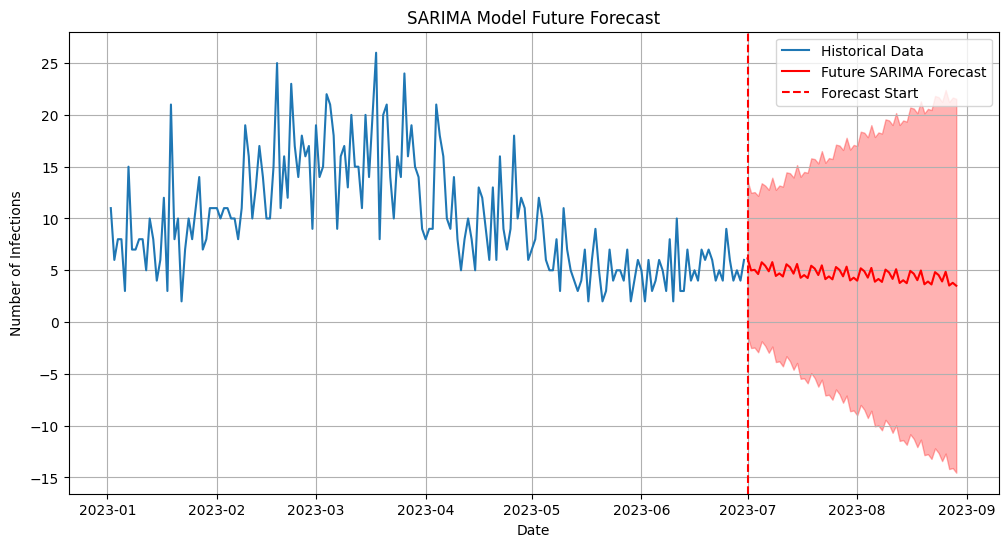

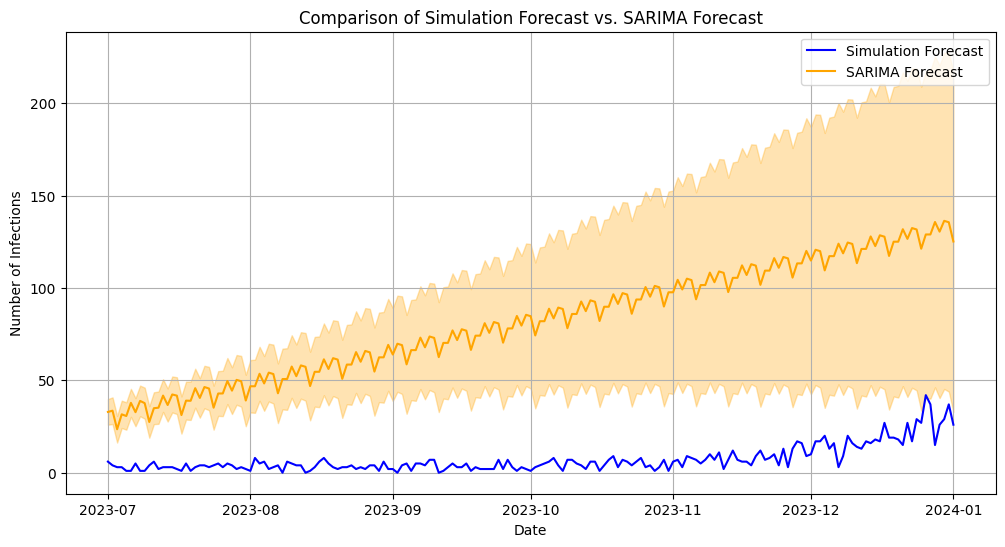

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# Function to load and prepare data
def load_and_prepare_data(run1_zip_path, run2_zip_path):
    with zipfile.ZipFile(run1_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/run1_extracted')
        csv_file_path = '/content/run1_extracted/run1/klaipeda-measures_lt.csv'
        run1_df = pd.read_csv(csv_file_path)

    with zipfile.ZipFile(run2_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/run2_extracted')
        simulation_csv_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
        simulation_df = pd.read_csv(simulation_csv_path)

    run1_df['date'] = pd.to_datetime(run1_df['date'], dayfirst=True)
    simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)

    run1_df.set_index('date', inplace=True)
    run1_df.sort_index(inplace=True)

    simulation_df = simulation_df[simulation_df['date'] >= '2023-07-01']

    return run1_df, simulation_df

# Function to fit SARIMA model and forecast
def fit_sarima_and_forecast(data, order=(1, 1, 2), seasonal_order=(1, 1, 1, 7), steps=60):
    model = SARIMAX(data, order=order, seasonal_order=seasonal_order)
    sarima_model = model.fit(disp=False)

    forecast = sarima_model.get_forecast(steps=steps)
    forecast_values = forecast.predicted_mean
    conf_int = forecast.conf_int()

    return forecast_values, conf_int

# Function to plot forecasts and actual values
def plot_forecast(test, forecast_values, conf_int, title='Predicted vs Actual Data', label='Predicted'):
    plt.figure(figsize=(12, 6))
    plt.plot(test.index, test, label='Actual')
    plt.plot(test.index, forecast_values, color='orange', label=label)
    plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.3)
    plt.axvline(pd.to_datetime('2023-07-01'), color='red', linestyle='--', label='forecast starts')

    plt.xlabel('Date')
    plt.ylabel('Number of Infections')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to plot comparison between SARIMA and Simulation Forecasts
def plot_comparison(simulation_df, sarima_forecast_values, sarima_forecast_conf_int_df):
    plt.figure(figsize=(12, 6))

    # Plot the simulation forecast
    plt.plot(simulation_df['date'], simulation_df['num infections today'], label='Simulation Forecast', color='blue')

    # Plot the SARIMA forecast
    plt.plot(simulation_df['date'], sarima_forecast_values, label='SARIMA Forecast', color='orange')

    # Add confidence intervals
    plt.fill_between(simulation_df['date'], sarima_forecast_conf_int_df['lower'],
                     sarima_forecast_conf_int_df['upper'], color='orange', alpha=0.3)

    plt.xlabel('Date')
    plt.ylabel('Number of Infections')
    plt.title('Comparison of Simulation Forecast vs. SARIMA Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()

# Main script
run1_zip_path = '/run1.zip'
run2_zip_path = '/run2.zip'

# Load and prepare the data
run1_df, simulation_df = load_and_prepare_data(run1_zip_path, run2_zip_path)

# Focus on the "num infections today" column for SARIMA model
train_size = int(len(run1_df) * 0.8)
train, test = run1_df['num infections today'][:train_size], run1_df['num infections today'][train_size:]

# Fit SARIMA model and forecast future values (for the test set)
sarima_forecast_values, sarima_conf_int = fit_sarima_and_forecast(train, steps=len(test))

# Evaluate the model
rmse = np.sqrt(mean_squared_error(test, sarima_forecast_values))
print(f'Test RMSE: {rmse}')

# Plot the forecast against actual values
plot_forecast(test, sarima_forecast_values, sarima_conf_int)

# Forecast future values beyond the test set
future_forecast_values, future_conf_int = fit_sarima_and_forecast(run1_df['num infections today'], steps=60)

# Ensure the index of the future_forecast_values is continuous for plotting
future_forecast_index = pd.date_range(start=run1_df.index[-1], periods=61, freq='D')[1:]

# Plot the future forecast
plt.figure(figsize=(12, 6))
plt.plot(run1_df.index, run1_df['num infections today'], label='Historical Data')
plt.plot(future_forecast_index, future_forecast_values, color='red', label='Future SARIMA Forecast')
plt.fill_between(future_forecast_index, future_conf_int.iloc[:, 0], future_conf_int.iloc[:, 1], color='red', alpha=0.3)
plt.axvline(pd.to_datetime('2023-07-01'), color='red', linestyle='--', label='Forecast Start')

plt.xlabel('Date')
plt.ylabel('Number of Infections')
plt.title('SARIMA Model Future Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Fit SARIMA model on the simulation forecast data and compare
sarima_forecast_values_sim, sarima_forecast_conf_int = fit_sarima_and_forecast(simulation_df['num infections today'].values, steps=len(simulation_df))
sarima_forecast_conf_int_df = pd.DataFrame(sarima_forecast_conf_int, columns=['lower', 'upper'])

# Plot comparison between simulation and SARIMA forecasts
plot_comparison(simulation_df, sarima_forecast_values_sim, sarima_forecast_conf_int_df)


### Model Comparison

In [ ]:

import plotly.graph_objs as go
from plotly.subplots import make_subplots
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Load Simple and Stacked LSTM forecasted data
simple_lstm_df = pd.read_csv('/content/forecasted_infections.csv')
stacked_lstm_df = pd.read_csv('/content/stacked_forecasted_infections.csv')

# Step 1: Load and Prepare Simulation and Historical Data (Run 1 and Run 2)
def load_simulation_data():
    # Load directly from extracted folders
    run1_csv_path = '/content/run1_extracted/run1/klaipeda-measures_lt.csv'
    run2_csv_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'

    run1_df = pd.read_csv(run1_csv_path)
    simulation_df = pd.read_csv(run2_csv_path)

    # Format date columns
    run1_df['date'] = pd.to_datetime(run1_df['date'], dayfirst=True)
    simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)

    # Fix potential 'SettingWithCopyWarning' using .loc
    simulation_df = simulation_df.loc[simulation_df['date'] >= '2023-07-01'].copy()
    simulation_df = simulation_df[['date', 'num infections today']].rename(columns={'num infections today': 'simulation_forecast'})

    return run1_df, simulation_df

# Load simulation and historical data
run1_df, simulation_df = load_simulation_data()

# Check if run1_df has dates, get the last date
if run1_df.empty:
    raise ValueError("run1_df is empty. Please check the data source.")

last_date_run1 = run1_df['date'].max()

# Limit simulation forecast to 60 days
simulation_df = simulation_df.head(60)

# Step 2: Prophet Model Forecast
def fit_prophet_and_forecast(run1_df):
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    run1_df_prophet = run1_df[['date', 'num infections today']].copy()
    run1_df_prophet.rename(columns={'date': 'ds', 'num infections today': 'y'}, inplace=True)
    model.fit(run1_df_prophet)

    future_dates = model.make_future_dataframe(periods=60)
    forecast = model.predict(future_dates)
    forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))  # Ensure no negative values
    return forecast[['ds', 'yhat']]

# Step 3: SARIMA Model Forecast
def fit_sarima_and_forecast(data, order=(1, 1, 2), seasonal_order=(1, 1, 1, 7), steps=60):
    model = SARIMAX(data, order=order, seasonal_order=seasonal_order)
    sarima_model = model.fit(disp=False)
    forecast = sarima_model.get_forecast(steps=steps)
    forecast_values = forecast.predicted_mean
    conf_int = forecast.conf_int()
    return forecast_values, conf_int

# Prophet forecast
prophet_forecast = fit_prophet_and_forecast(run1_df).head(60)

# SARIMA forecast
sarima_forecast_values, sarima_conf_int = fit_sarima_and_forecast(run1_df['num infections today'], steps=60)

# Align Prophet forecast with simulation data
prophet_forecast_aligned = pd.merge(
    simulation_df[['date']],
    prophet_forecast[['ds', 'yhat']],
    left_on='date',
    right_on='ds',
    how='inner'
)
prophet_forecast_aligned.rename(columns={'yhat': 'prophet_forecast'}, inplace=True)

# Step 4: Generate synthetic dates for Stacked LSTM forecast if 'date' not present
if 'date' not in stacked_lstm_df.columns:
    # Assume the start date is the day after the last date in run1_df
    start_date = last_date_run1 + pd.Timedelta(days=1)
    stacked_lstm_df['date'] = pd.date_range(start=start_date, periods=len(stacked_lstm_df))
else:
    # Ensure 'date' is in datetime format
    stacked_lstm_df['date'] = pd.to_datetime(stacked_lstm_df['date'], dayfirst=True)
# Ensure 'date' columns are in datetime format for Simple LSTM
# simple_lstm_df['date'] = pd.to_datetime(simple_lstm_df['date'], dayfirst=True) #Original code
simple_lstm_df['date'] = pd.to_datetime(simple_lstm_df['date'], format='%Y-%m-%d') # Changed the format to match the format of the date column in the CSV
# Step 5: Plot Comparison of Forecasts
def plot_comparison(simulation_df, prophet_forecast_aligned, simple_lstm_df, stacked_lstm_df, sarima_forecast_values):
    fig = make_subplots(rows=1, cols=1)

    # Add Simulation Forecast
    fig.add_trace(go.Scatter(
        x=simulation_df['date'],
        y=simulation_df['simulation_forecast'],
        mode='lines',
        name='Simulation Forecast',
        line=dict(color='blue')
    ))

    # Add Simple LSTM Forecast
    fig.add_trace(go.Scatter(
        x=simple_lstm_df['date'],
        y=simple_lstm_df['forecasted_num_infections'],
        mode='lines',
        name='Simple LSTM Forecast',
        line=dict(color='green')
    ))

    # Add Stacked LSTM Forecast
    fig.add_trace(go.Scatter(
        x=stacked_lstm_df['date'],
        y=stacked_lstm_df['forecasted_num_infections'],
        mode='lines',
        name='Stacked LSTM Forecast',
        line=dict(color='purple')
    ))

    # Add Prophet Forecast
    fig.add_trace(go.Scatter(
        x=prophet_forecast_aligned['date'],
        y=prophet_forecast_aligned['prophet_forecast'],
        mode='lines',
        name='Prophet Forecast',
        line=dict(color='orange')
    ))

    # Add SARIMA Forecast
    sarima_forecast_df = pd.DataFrame({
        'date': pd.date_range(start=last_date_run1 + pd.Timedelta(days=1), periods=60),
        'sarima_forecast': sarima_forecast_values.values
    })
    fig.add_trace(go.Scatter(
        x=sarima_forecast_df['date'],
        y=sarima_forecast_df['sarima_forecast'],
        mode='lines',
        name='SARIMA Forecast',
        line=dict(color='red')
    ))

    # Update layout for interactive features
    fig.update_layout(
        title='Interactive Comparison of Forecasts',
        xaxis_title='Date',
        yaxis_title='Number of Infections',
        hovermode='x unified',
        showlegend=True
    )

    # Add interactive rangeslider and zoom options
    fig.update_xaxes(rangeslider_visible=True)
    fig.update_yaxes(fixedrange=False)

    # Show the interactive plot
    fig.show()

# Step 6: Plot the Comparison
plot_comparison(simulation_df, prophet_forecast_aligned, simple_lstm_df, stacked_lstm_df, sarima_forecast_values)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/oj9ri__5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/q9bz11p9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19996', 'data', 'file=/tmp/tmp9g28p825/oj9ri__5.json', 'init=/tmp/tmp9g28p825/q9bz11p9.json', 'output', 'file=/tmp/tmp9g28p825/prophet_modelb_65r609/prophet_model-20240920165821.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:58:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:58:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects inst

In [ ]:
# Prophet forecast
prophet_forecast = fit_prophet_and_forecast(run1_df).head(60)

# Ensure that both 'date' columns are in the same format
simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
prophet_forecast['ds'] = pd.to_datetime(prophet_forecast['ds'])

# Check the date range of Prophet's forecast to ensure it overlaps with simulation data
min_prophet_date = prophet_forecast['ds'].min()
max_prophet_date = prophet_forecast['ds'].max()

# Debugging output to ensure correct date range
print("Prophet Forecast Date Range:", min_prophet_date, "to", max_prophet_date)
print("Simulation Data Date Range:", simulation_df['date'].min(), "to", simulation_df['date'].max())

# Filter Prophet forecast to match simulation date range
prophet_forecast_filtered = prophet_forecast[prophet_forecast['ds'].isin(simulation_df['date'])]

# Check the filtered result
print(prophet_forecast_filtered.head())

# Merge Prophet forecast with simulation data on matching dates
prophet_forecast_aligned = pd.merge(
    simulation_df[['date']],
    prophet_forecast_filtered[['ds', 'yhat']],
    left_on='date',
    right_on='ds',
    how='inner'
)

# Rename Prophet forecast column for clarity
prophet_forecast_aligned.rename(columns={'yhat': 'prophet_forecast'}, inplace=True)

# Ensure the merge worked
print("Prophet Forecast Aligned:\n", prophet_forecast_aligned.head())

# Prophet Model Forecast for July 2023 onwards
def fit_prophet_and_forecast_for_july(run1_df):
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)

    # Only use data up until June 30, 2023 for training
    run1_df_prophet = run1_df[run1_df['date'] < '2023-07-01'][['date', 'num infections today']].copy()
    run1_df_prophet.rename(columns={'date': 'ds', 'num infections today': 'y'}, inplace=True)

    # Train the Prophet model
    model.fit(run1_df_prophet)

    # Forecast from July 1, 2023 for 60 days
    future_dates = pd.date_range(start='2023-07-01', periods=60, freq='D')
    future_df = pd.DataFrame({'ds': future_dates})

    # Generate the forecast
    forecast = model.predict(future_df)

    # Ensure no negative values
    forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))

    return forecast[['ds', 'yhat']]

# Use the updated Prophet function to get the forecast starting from July
prophet_forecast = fit_prophet_and_forecast_for_july(run1_df)

# Align Prophet forecast with simulation data
prophet_forecast_aligned = pd.merge(
    simulation_df[['date']],
    prophet_forecast[['ds', 'yhat']],
    left_on='date',
    right_on='ds',
    how='inner'
)
prophet_forecast_aligned.rename(columns={'yhat': 'prophet_forecast'}, inplace=True)

# Check if the Prophet forecast is now aligned with the simulation data
print("Prophet Forecast Aligned:\n", prophet_forecast_aligned.head())

# Proceed with plotting as before
plot_comparison(simulation_df, prophet_forecast_aligned, simple_lstm_df, stacked_lstm_df, sarima_forecast_values)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/5_okdolm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/3hxgcacl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=65666', 'data', 'file=/tmp/tmp9g28p825/5_okdolm.json', 'init=/tmp/tmp9g28p825/3hxgcacl.json', 'output', 'file=/tmp/tmp9g28p825/prophet_modelyzifql6r/prophet_model-20240920165832.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:58:32 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:58:32 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/k_n9ff26.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/rohahabv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

Prophet Forecast Date Range: 2023-01-02 00:00:00 to 2023-03-02 00:00:00
Simulation Data Date Range: 2023-07-01 00:00:00 to 2023-08-29 00:00:00
Empty DataFrame
Columns: [ds, yhat]
Index: []
Prophet Forecast Aligned:
 Empty DataFrame
Columns: [date, ds, prophet_forecast]
Index: []
Prophet Forecast Aligned:
         date         ds  prophet_forecast
0 2023-07-01 2023-07-01                 7
1 2023-07-02 2023-07-02                 5
2 2023-07-03 2023-07-03                 6
3 2023-07-04 2023-07-04                 6
4 2023-07-05 2023-07-05                 7


/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load Simple and Stacked LSTM forecasted data
simple_lstm_df = pd.read_csv('/content/forecasted_infections.csv')
stacked_lstm_df = pd.read_csv('/content/stacked_forecasted_infections.csv')

# Load and Prepare Simulation and Historical Data (Run 1 and Run 2)
def load_simulation_data():
    run1_df = pd.read_csv('/content/run1_extracted/run1/klaipeda-measures_lt.csv')
    simulation_df = pd.read_csv('/content/run2_extracted/run2/klaipeda-measures_lt.csv')

    run1_df['date'] = pd.to_datetime(run1_df['date'], dayfirst=True)
    simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
    simulation_df = simulation_df.loc[simulation_df['date'] >= '2023-07-01', ['date', 'num infections today']].rename(columns={'num infections today': 'simulation_forecast'})

    return run1_df, simulation_df

run1_df, simulation_df = load_simulation_data()
last_date_run1 = run1_df['date'].max()
simulation_df = simulation_df.head(60)

# Prophet Model Forecast for July 2023 onwards
def fit_prophet_and_forecast_for_july(run1_df):
    model = Prophet(yearly_seasonality=True, daily_seasonality=False)
    run1_df_prophet = run1_df[run1_df['date'] < '2023-07-01'][['date', 'num infections today']].rename(columns={'date': 'ds', 'num infections today': 'y'})

    model.fit(run1_df_prophet)
    future_dates = pd.date_range(start='2023-07-01', periods=60, freq='D')
    future_df = pd.DataFrame({'ds': future_dates})
    forecast = model.predict(future_df)
    forecast['yhat'] = forecast['yhat'].apply(lambda x: max(round(x), 0))  # Remove negative values

    return forecast[['ds', 'yhat']]

# Get Prophet forecast
prophet_forecast = fit_prophet_and_forecast_for_july(run1_df)
prophet_forecast_aligned = pd.merge(simulation_df[['date']], prophet_forecast[['ds', 'yhat']], left_on='date', right_on='ds', how='inner').rename(columns={'yhat': 'prophet_forecast'})

# SARIMA Model Forecast
def fit_sarima_and_forecast(data, steps=60):
    model = SARIMAX(data, order=(1, 1, 2), seasonal_order=(1, 1, 1, 7))
    sarima_model = model.fit(disp=False)
    forecast_values = sarima_model.get_forecast(steps=steps).predicted_mean
    return forecast_values

sarima_forecast_values = fit_sarima_and_forecast(run1_df['num infections today'], steps=60)

# Generate synthetic dates for LSTM forecasts if not available
if 'date' not in stacked_lstm_df.columns:
    stacked_lstm_df['date'] = pd.date_range(start=last_date_run1 + pd.Timedelta(days=1), periods=len(stacked_lstm_df))

simple_lstm_df['date'] = pd.to_datetime(simple_lstm_df['date'], format='%Y-%m-%d')
stacked_lstm_df['date'] = pd.to_datetime(stacked_lstm_df['date'], dayfirst=True)

# Plot Comparison of Forecasts
def plot_comparison(simulation_df, prophet_forecast_aligned, simple_lstm_df, stacked_lstm_df, sarima_forecast_values):
    fig = make_subplots(rows=1, cols=1)

    fig.add_trace(go.Scatter(x=simulation_df['date'], y=simulation_df['simulation_forecast'], mode='lines', name='Simulation Forecast', line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=simple_lstm_df['date'], y=simple_lstm_df['forecasted_num_infections'], mode='lines', name='Simple LSTM Forecast', line=dict(color='green')))
    fig.add_trace(go.Scatter(x=stacked_lstm_df['date'], y=stacked_lstm_df['forecasted_num_infections'], mode='lines', name='Stacked LSTM Forecast', line=dict(color='purple')))
    fig.add_trace(go.Scatter(x=prophet_forecast_aligned['date'], y=prophet_forecast_aligned['prophet_forecast'], mode='lines', name='Prophet Forecast', line=dict(color='orange')))

    sarima_forecast_df = pd.DataFrame({'date': pd.date_range(start=last_date_run1 + pd.Timedelta(days=1), periods=60), 'sarima_forecast': sarima_forecast_values.values})
    fig.add_trace(go.Scatter(x=sarima_forecast_df['date'], y=sarima_forecast_df['sarima_forecast'], mode='lines', name='SARIMA Forecast', line=dict(color='red')))

    fig.update_layout(title='Forecast Comparison', xaxis_title='Date', yaxis_title='Number of Infections', hovermode='x unified', showlegend=True)
    fig.update_xaxes(rangeslider_visible=True)
    fig.show()

plot_comparison(simulation_df, prophet_forecast_aligned, simple_lstm_df, stacked_lstm_df, sarima_forecast_values)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/jaa86w21.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp9g28p825/hq_f02ne.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=39811', 'data', 'file=/tmp/tmp9g28p825/jaa86w21.json', 'init=/tmp/tmp9g28p825/hq_f02ne.json', 'output', 'file=/tmp/tmp9g28p825/prophet_modeljmz6zsd9/prophet_model-20240920165841.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:58:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:58:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.10/dist-packages/_plotly_utils/basevalidators.py:105: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects inst

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Function to calculate error metrics including ARD with safe division for ARD
def calculate_error_metrics(true_values, predicted_values):
    mse = mean_squared_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true_values, predicted_values)
    mape = mean_absolute_percentage_error(true_values, predicted_values)

    # Safe ARD calculation (avoid division by zero)
    relative_difference = np.abs(true_values - predicted_values) / np.where(true_values != 0, true_values, np.nan)
    ard = np.nanmean(relative_difference)  # Compute mean ignoring NaN values
    return mse, rmse, mae, mape, ard

# Load simulation data from run2.zip (July onwards)
simulation_csv_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
simulation_df = pd.read_csv(simulation_csv_path)
simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
simulation_df = simulation_df[simulation_df['date'] >= '2023-07-01'].head(60)

# Extract the forecasted values for comparison
simulation_values = simulation_df['num infections today'].values
simple_lstm_values = simple_lstm_df['forecasted_num_infections'].values
stacked_lstm_values = stacked_lstm_df['forecasted_num_infections'].values
prophet_values = prophet_forecast_aligned['prophet_forecast'].values
sarima_values = sarima_forecast_values[:60].values  # Ensure the forecast horizon matches

# Calculate error metrics for each model
metrics_data = {
    'Model': ['Simulation Forecast', 'Simple LSTM', 'Stacked LSTM', 'Prophet', 'SARIMA'],
    'MSE': [],
    'RMSE': [],
    'MAE': [],
    'MAPE': [],
    'ARD': []  # Average Relative Difference
}

# Simulation Forecast (compared with itself, hence all values will be zero)
mse, rmse, mae, mape, ard = calculate_error_metrics(simulation_values, simulation_values)
metrics_data['MSE'].append(mse)
metrics_data['RMSE'].append(rmse)
metrics_data['MAE'].append(mae)
metrics_data['MAPE'].append(mape)
metrics_data['ARD'].append(ard)

# Simple LSTM
mse, rmse, mae, mape, ard = calculate_error_metrics(simulation_values, simple_lstm_values)
metrics_data['MSE'].append(mse)
metrics_data['RMSE'].append(rmse)
metrics_data['MAE'].append(mae)
metrics_data['MAPE'].append(mape)
metrics_data['ARD'].append(ard)

# Stacked LSTM
mse, rmse, mae, mape, ard = calculate_error_metrics(simulation_values, stacked_lstm_values)
metrics_data['MSE'].append(mse)
metrics_data['RMSE'].append(rmse)
metrics_data['MAE'].append(mae)
metrics_data['MAPE'].append(mape)
metrics_data['ARD'].append(ard)

# Prophet
mse, rmse, mae, mape, ard = calculate_error_metrics(simulation_values, prophet_values)
metrics_data['MSE'].append(mse)
metrics_data['RMSE'].append(rmse)
metrics_data['MAE'].append(mae)
metrics_data['MAPE'].append(mape)
metrics_data['ARD'].append(ard)

# SARIMA
mse, rmse, mae, mape, ard = calculate_error_metrics(simulation_values, sarima_values)
metrics_data['MSE'].append(mse)
metrics_data['RMSE'].append(rmse)
metrics_data['MAE'].append(mae)
metrics_data['MAPE'].append(mape)
metrics_data['ARD'].append(ard)

# Create a DataFrame to display the error metrics
error_metrics_df = pd.DataFrame(metrics_data)

# Display the error metrics table
print("Error Metrics Table:")
print(error_metrics_df)


Error Metrics Table:
                 Model         MSE       RMSE        MAE          MAPE  \
0  Simulation Forecast    0.000000   0.000000   0.000000  0.000000e+00   
1          Simple LSTM  195.766507  13.991658  13.550394  2.784822e+15   
2         Stacked LSTM   20.640539   4.543186   3.794204  9.135550e+14   
3              Prophet   10.283333   3.206764   2.716667  7.505999e+14   
4               SARIMA    5.039661   2.244919   1.807672  5.743881e+14   

        ARD  
0  0.000000  
1  5.594954  
2  1.793188  
3  1.413793  
4  0.977090  


In [ ]:

# Function to calculate ARD with safe division for ARD
def calculate_ard(true_values, predicted_values):
    relative_difference = np.abs(true_values - predicted_values) / np.where(true_values != 0, true_values, np.nan)
    ard = np.nanmean(relative_difference)  # Compute mean ignoring NaN values
    return ard

# Load simulation data from run2.zip (July onwards)
simulation_csv_path = '/content/run2_extracted/run2/klaipeda-measures_lt.csv'
simulation_df = pd.read_csv(simulation_csv_path)
simulation_df['date'] = pd.to_datetime(simulation_df['date'], dayfirst=True)
simulation_df = simulation_df[simulation_df['date'] >= '2023-07-01'].head(60)

# Extract the forecasted values for comparison
simulation_values = simulation_df['num infections today'].values
zip2_forecast_values = stacked_lstm_df['forecasted_num_infections'].values

# Calculate ARD for zip 2 forecast
ard_zip2 = calculate_ard(simulation_values, zip2_forecast_values)

print("ARD for Zip 2 Forecast (July onwards):", ard_zip2)


ARD for Zip 2 Forecast (July onwards): 1.793188252964796
